# Analytics - Product Quality

#### Date: 2026/04

#### SUMMARY:

- This notebook represents the project quality analysis of the date exposed right above.

### TEAM:

##### Semester: 2026/01
##### Professor: Hilmer Neri

##### Members:

- Ana Catarina Lopes e Vasconcelos
- Arthur Carneiro Trindade
- Bruno Ricardo de Menezes
- Breno Soares Fernandes
- Caio Brandão Santos
- Genilson Silva de Araújo Júnior
- João Vitor Lopes Ribeiro
- Kathlyn Lara Murussi
- Maria Luisa Alves Rodrigues
- Miguel Moreira de Oliveira
- Pedro Cabeceira de Freitas
- Victor Hugo Rodrigues Guimarães


### LIBRARIES

In [1]:
import pandas as pd
import json
from glob import glob
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

### GRAPH SETTINGS

In [2]:
%config InlineBackend.figure_format = 'retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid',
              {'xtick.bottom': True,
               'ytick.left': True,
               'grid.linestyle': '--',
               'font.monospace': ['Computer Modern Typewriter'],
               'axes.edgecolor': 'white'})

### DATAFRAME SETTINGS

In [3]:
pd.set_option('display.max_rows', None, 'display.max_columns', None)

### PROJECT CONFIG

Os JSONs foram gerados pelo CI via `/api/measures/component` — cada arquivo contém as
métricas **agregadas do projeto inteiro** (um único objeto `component`).

Padrão do nome:
`fga-eps-mds-2026_1_UNB-AnatoQuizUp-{REPO}-MM-DD-YYYY-HH-MM-SS-vX.Y.Z.json`

Subdiretório determina o repositório:
- `analytics-raw-data/backend/`  → API
- `analytics-raw-data/frontend/` → WEB

In [4]:
FILE_PREFIX = 'fga-eps-mds-2026_1_UNB-AnatoQuizUp-'

repos_config = {
    'backend':  'API',
    'frontend': 'WEB',
}

### SONARCLOUD — Carregar arquivos de métricas

In [ ]:
sonar_files = []
for folder, repo in repos_config.items():
    files = glob(f'./analytics-raw-data/{folder}/fga-eps-mds-*.json')
    files = [f for f in files if 'latest' not in os.path.basename(f)]
    for f in files:
        sonar_files.append({'path': f, 'folder': folder, 'repo': repo})

print(f'{len(sonar_files)} arquivo(s) encontrado(s):')
for sf in sonar_files:
    print(f"  [{sf['repo']}] {os.path.basename(sf['path'])}")

6 arquivo(s) encontrado(s):
  [API] fga-eps-mds-2026_1_UNB-AnatoQuizUp-Back-04-27-2026-02-33-15-v1.0.0.json
  [API] fga-eps-mds-2026_1_UNB_AnatoQuizUp-Back-04-01-2026-00-00-00-v0.0.0.json
  [API] fga-eps-mds-2026_1_UNB_AnatoQuizUp-Back-04-10-2026-00-00-00-v0.0.0.json
  [WEB] fga-eps-mds-2026_1_UNB-AnatoQuizUp-Front-04-27-2026-02-16-43-v0.0.0.json
  [WEB] fga-eps-mds-2026_1_UNB_AnatoQuizUp-Front-04-01-2026-04-01-00-v0.0.0.json
  [WEB] fga-eps-mds-2026_1_UNB_AnatoQuizUp-Front-04-10-2026-00-00-00-v0.0.0.json
['backend', 'data', 'frontend']


### Funções de leitura e parse

In [6]:
metric_list = [
    'files', 'functions', 'complexity', 'comment_lines_density',
    'duplicated_lines_density', 'coverage', 'ncloc', 'tests',
    'test_errors', 'test_failures', 'test_execution_time', 'security_rating'
]

In [7]:
def parse_filename(base_name: str):
    """
    Extrai datetime e version do nome do arquivo.
    Ex: fga-eps-mds-2026_1_UNB-AnatoQuizUp-API-04-27-2026-02-16-43-v0.0.0.json
    """
    pattern = r'-(\d{2}-\d{2}-\d{4}-\d{2}-\d{2}-\d{2})-(v[\d.]+)\.json$'
    match = re.search(pattern, base_name)
    if match:
        return match.group(1), match.group(2)
    return 'unknown', 'unknown'


def extract_measures(json_dict: dict) -> dict:
    """
    Lê JSON no formato /api/measures/component
    (sem 'data', direto em 'component')
    """
    component = json_dict.get('component', {})

    result = {}
    for m in component.get('measures', []):
        metric = m.get('metric')
        value  = m.get('value')

        if metric in metric_list:
            try:
                result[metric] = float(value)
            except (TypeError, ValueError):
                result[metric] = None
        
    for metric in metric_list:
        result.setdefault(metric, None)

    return result

### Criar DataFrame principal

In [8]:
def create_component_df(sonar_files_list) -> pd.DataFrame:
    rows = []
    for sf in sonar_files_list:
        base_name = os.path.basename(sf['path'])
        dt_str, version_str = parse_filename(base_name)
        with open(sf['path']) as f:
            json_dict = json.load(f)
        measures = extract_measures(json_dict)
        row = {
            'filename':   base_name,
            'repository': FILE_PREFIX + sf['repo'],
            'datetime':   dt_str,
            'version':    version_str,
            **measures
        }
        rows.append(row)

    df = pd.DataFrame(rows, columns=['filename','repository','datetime','version'] + metric_list)
    return df.sort_values(by=['repository','datetime']).reset_index(drop=True)


component_df = create_component_df(sonar_files)
component_df = component_df.fillna(0)
print('Repositórios:', component_df['repository'].unique())
component_df

Repositórios: ['fga-eps-mds-2026_1_UNB-AnatoQuizUp-API'
 'fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB']


C:\Users\torug\AppData\Local\Temp\ipykernel_4448\1663220835.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  component_df = component_df.fillna(0)


,filename,repository,datetime,version,files,functions,complexity,comment_lines_density,duplicated_lines_density,coverage,ncloc,tests,test_errors,test_failures,test_execution_time,security_rating
0,fga-eps-mds-2026_1_UNB_AnatoQuizUp-Back-04-01-...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-01-2026-00-00-00,v0.0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
1,fga-eps-mds-2026_1_UNB_AnatoQuizUp-Back-04-10-...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-10-2026-00-00-00,v0.0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
2,fga-eps-mds-2026_1_UNB-AnatoQuizUp-Back-04-27-...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-27-2026-02-33-15,v1.0.0,78.0,158.0,291.0,0.7,0.0,96.3,3082.0,0,0,0,0,1.0
3,fga-eps-mds-2026_1_UNB_AnatoQuizUp-Front-04-01...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-01-2026-04-01-00,v0.0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
4,fga-eps-mds-2026_1_UNB_AnatoQuizUp-Front-04-10...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-10-2026-00-00-00,v0.0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
5,fga-eps-mds-2026_1_UNB-AnatoQuizUp-Front-04-27...,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-27-2026-02-16-43,v0.0.0,53.0,205.0,525.0,0.4,0.0,85.8,2561.0,0,0,0,0,1.0


### Separar por repositório

In [9]:
repos_dataframes = []
for folder, repo in repos_config.items():
    repo_full = FILE_PREFIX + repo
    df = component_df[component_df['repository'] == repo_full].copy()
    repos_dataframes.append({'name': repo, 'df': df})
    print(f'{repo}: {len(df)} versão(ões)')

API: 3 versão(ões)
WEB: 3 versão(ões)


## Cálculo das métricas — modelo Q-Rapids

Como os dados vêm **agregados por projeto** (não por arquivo), as métricas
são calculadas diretamente dos totais retornados pelo SonarCloud:

| Métrica | Cálculo | Intervalo |
|---|---|---|
| **complexity** | `1 - (complexity/functions) / 10` — complexidade média por função normalizada | 0–1 |
| **comments** | `1.0` se `comment_lines_density` entre 10% e 30%, senão `0.0` | 0–1 |
| **duplication** | `1 - duplicated_lines_density / 5` — penaliza acima de 5% | 0–1 |
| **test_success** | `(tests − errors − failures) / tests` | 0–1 |
| **fast_tests** | `1.0` se suite < 5 min (300 000 ms), proporcional acima | 0–1 |
| **coverage** | `coverage / 100` | 0–1 |

In [10]:
def calc_complexity(row) -> float:
    try:
        ratio = float(row['complexity']) / float(row['functions'])
        return max(0.0, min(1.0, 1 - (ratio / 10)))
    except (TypeError, ValueError, ZeroDivisionError):
        return 0.0

def calc_comments(row) -> float:
    try:
        d = float(row['comment_lines_density'])
        return 1.0 if 10 <= d <= 30 else 0.0
    except (TypeError, ValueError):
        return 0.0

def calc_duplication(row) -> float:
    try:
        d = float(row['duplicated_lines_density'])
        return max(0.0, min(1.0, 1 - (d / 5)))
    except (TypeError, ValueError):
        return 0.0

def calc_test_success(row) -> float:
    try:
        total = float(row['tests'])
        if total == 0:
            return 0.0
        errors = float(row['test_errors'] or 0)
        fails  = float(row['test_failures'] or 0)
        return max(0.0, (total - errors - fails) / total)
    except (TypeError, ValueError):
        return 0.0

def calc_fast_tests(row) -> float:
    try:
        t = float(row['test_execution_time'])
        if t <= 0:
            return 0.0
        return max(0.0, min(1.0, 300000 / t))
    except (TypeError, ValueError):
        return 0.0

def calc_coverage(row) -> float:
    try:
        return max(0.0, min(1.0, float(row['coverage']) / 100))
    except (TypeError, ValueError):
        return 0.0


def create_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    result = df[['repository','datetime','version','ncloc']].copy()
    result['complexity']   = df.apply(calc_complexity,   axis=1)
    result['comments']     = df.apply(calc_comments,     axis=1)
    result['duplication']  = df.apply(calc_duplication,  axis=1)
    result['test_success'] = df.apply(calc_test_success, axis=1)
    result['fast_tests']   = df.apply(calc_fast_tests,   axis=1)
    result['coverage']     = df.apply(calc_coverage,     axis=1)
    return result.reset_index(drop=True)


metrics = {}
for repo_df in repos_dataframes:
    metrics[repo_df['name']] = create_metrics_df(repo_df['df'])

for name, data in metrics.items():
    print(f'\n=== {name} ===')
    display(data)


=== API ===


,repository,datetime,version,ncloc,complexity,comments,duplication,test_success,fast_tests,coverage
0,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-01-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000
1,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-10-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000
2,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-27-2026-02-33-15,v1.0.0,3082.0,0.815823,0.0,1.0,0.0,0.0,0.963



=== WEB ===


,repository,datetime,version,ncloc,complexity,comments,duplication,test_success,fast_tests,coverage
0,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-01-2026-04-01-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000
1,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-10-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000
2,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-27-2026-02-16-43,v0.0.0,2561.0,0.743902,0.0,1.0,0.0,0.0,0.858


## Visualização das métricas por repositório

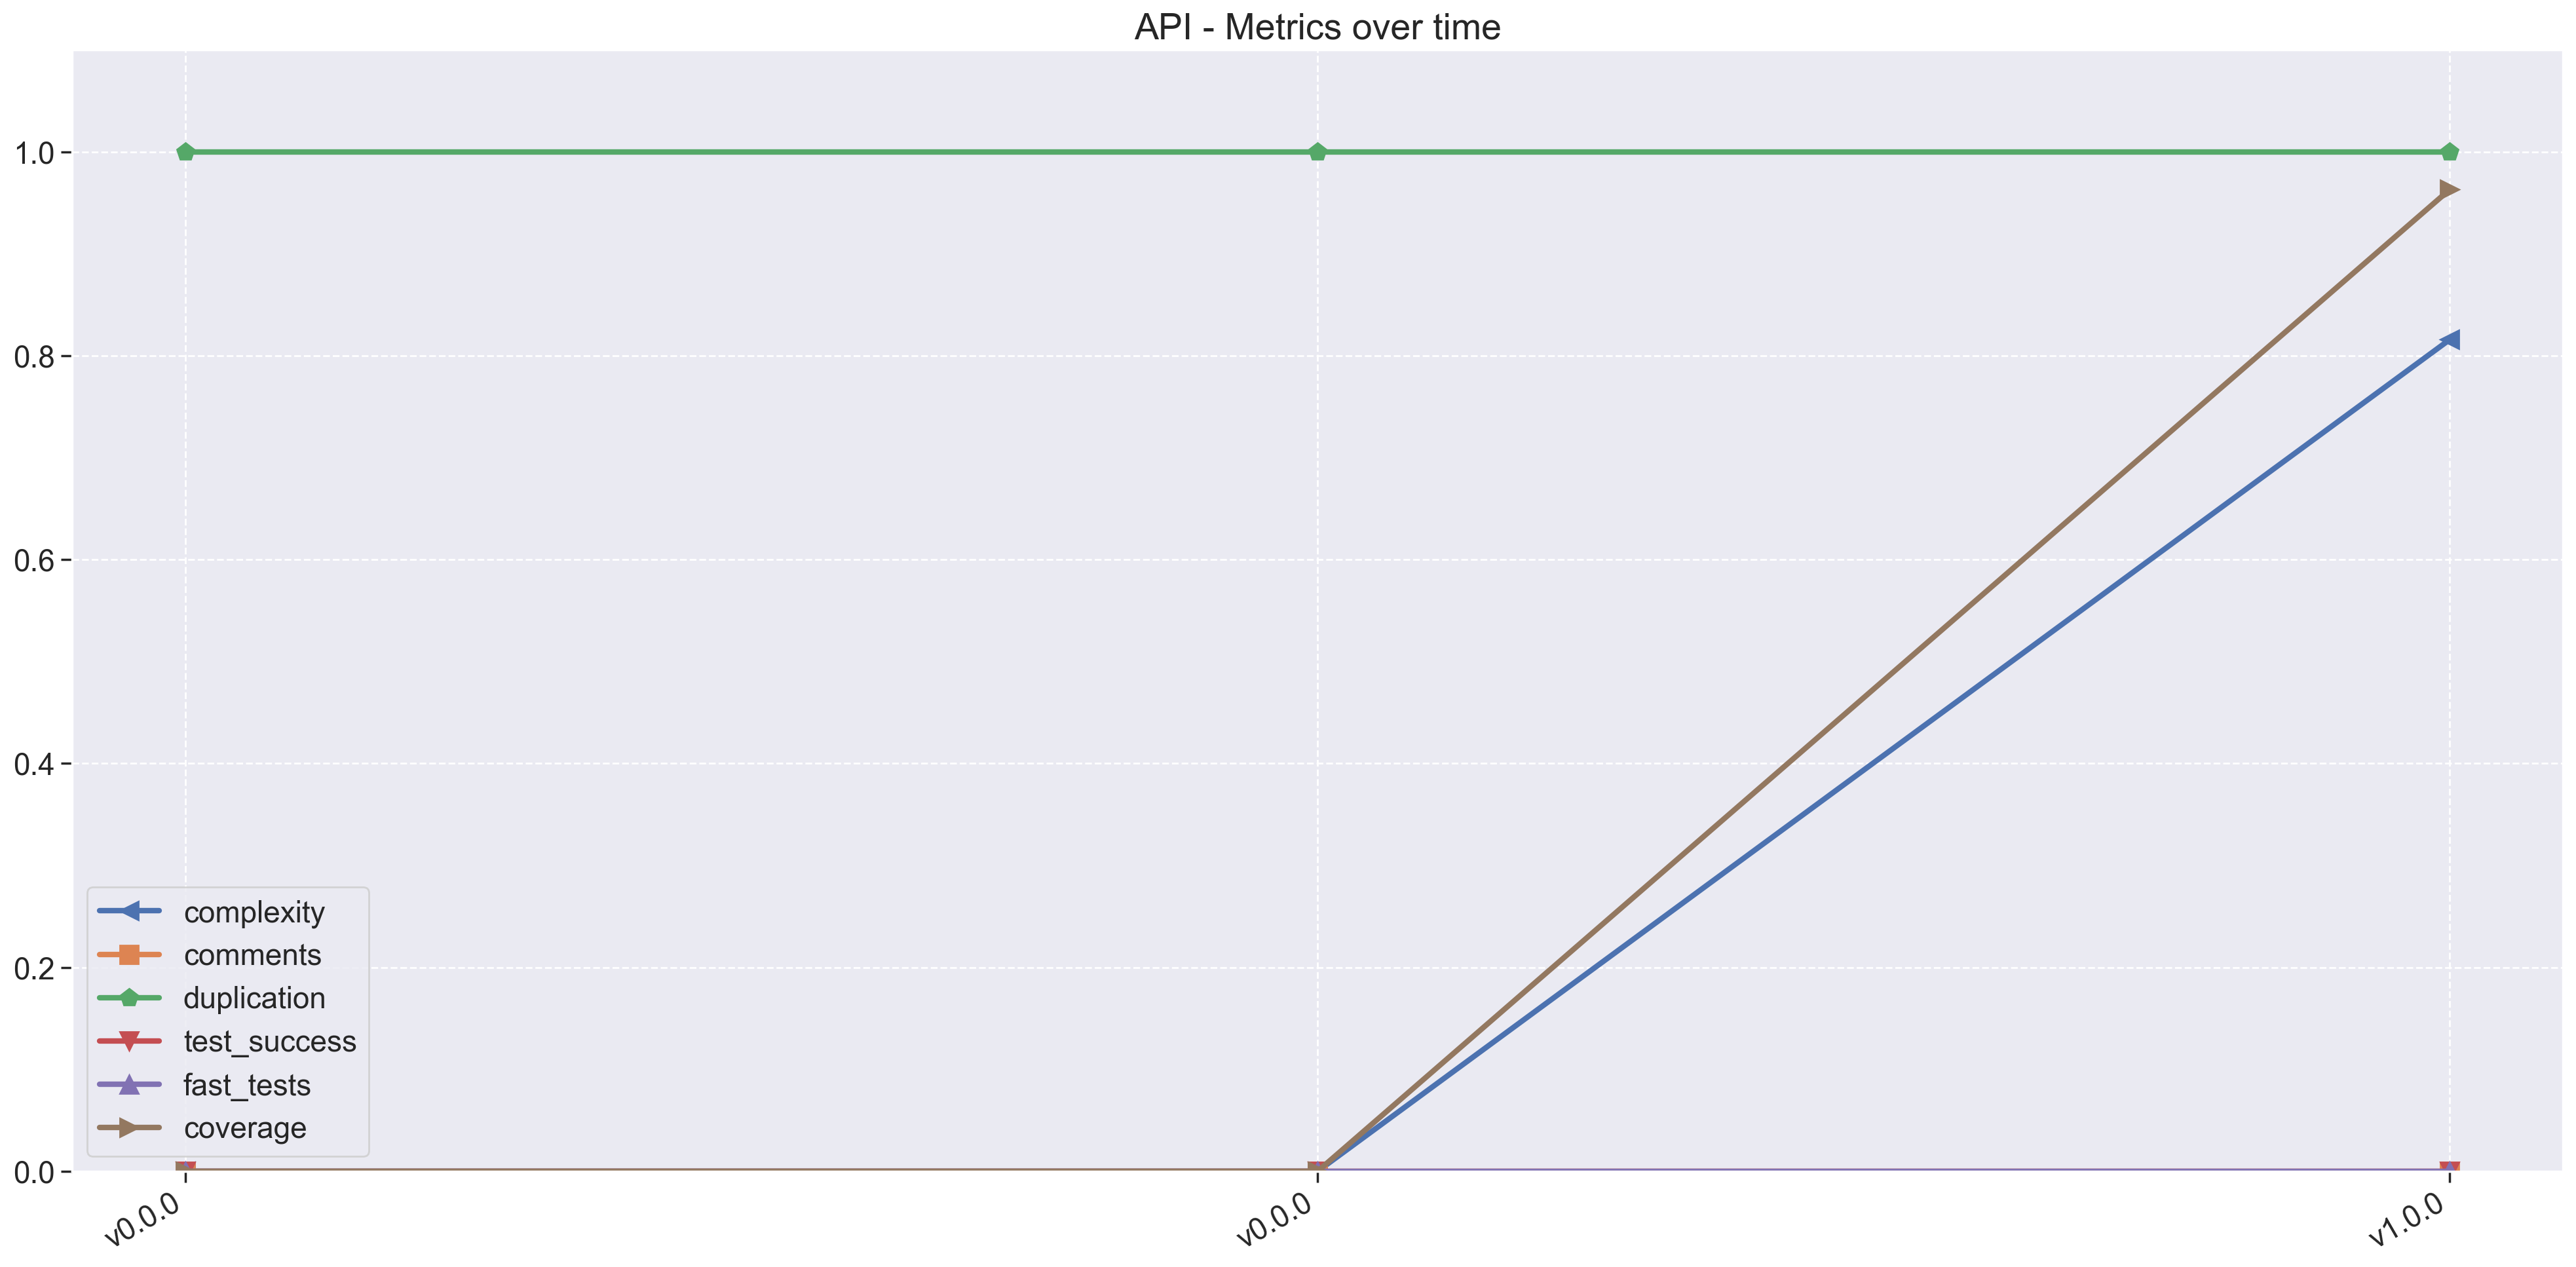

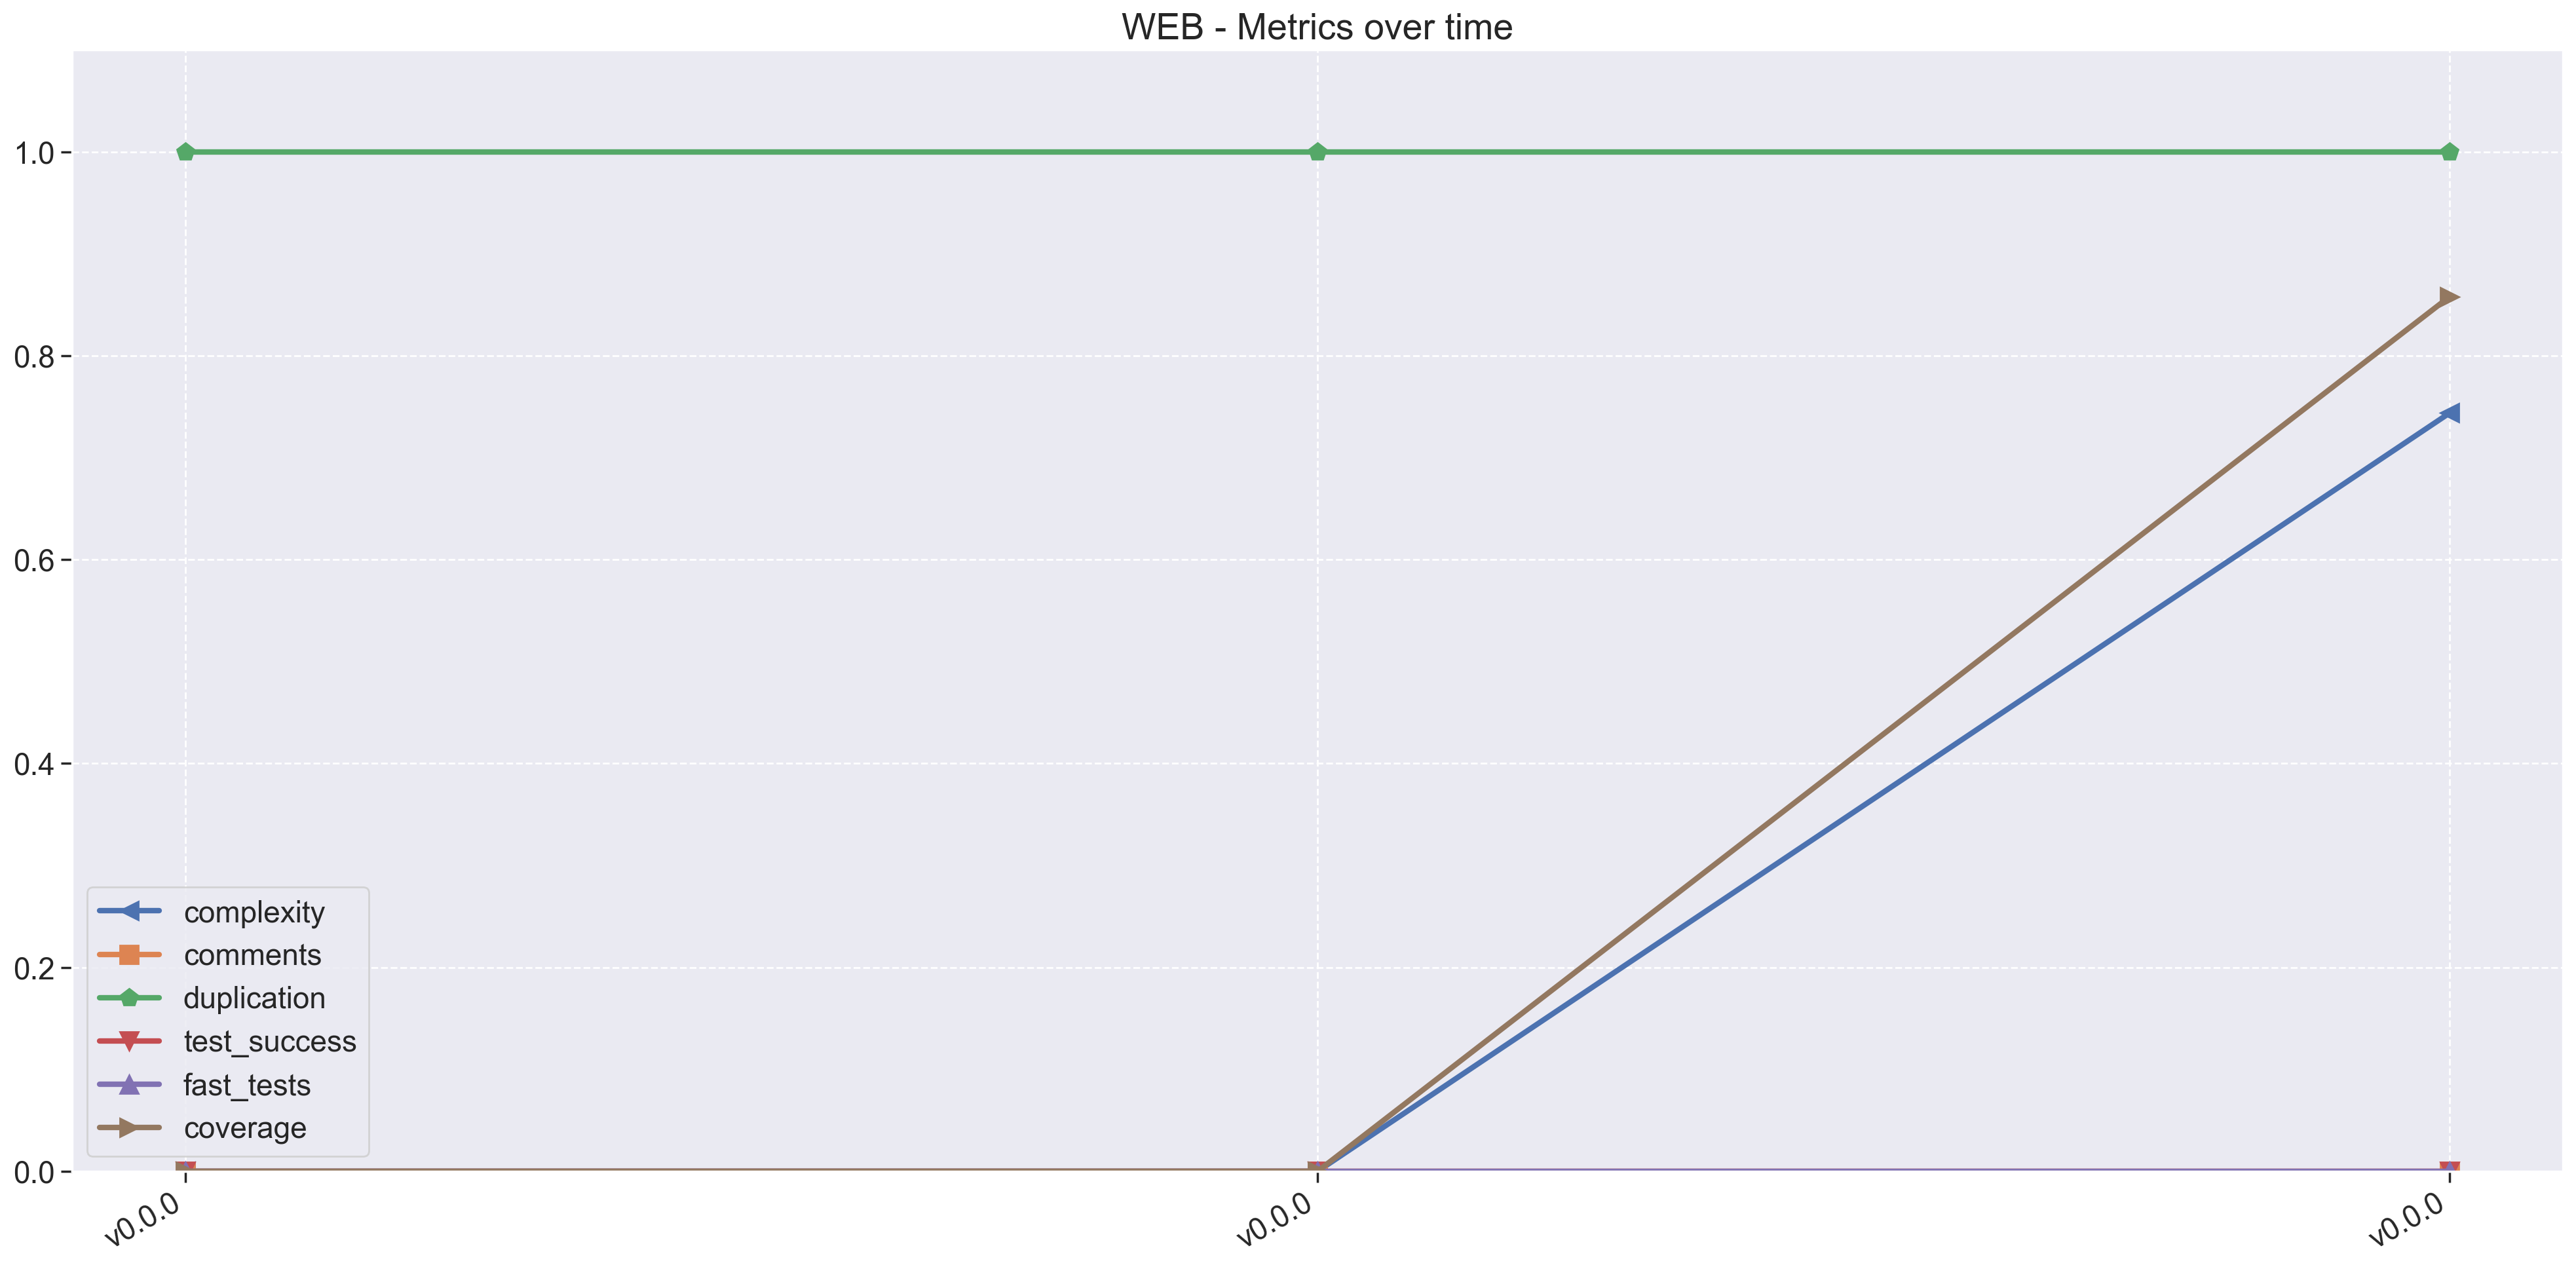

In [11]:
for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))
    x = range(len(data))
    labels = data['version'].tolist()
    plt.plot(x, data['complexity'],   linewidth=3, marker='<', markersize=10, label='complexity')
    plt.plot(x, data['comments'],     linewidth=3, marker='s', markersize=10, label='comments')
    plt.plot(x, data['duplication'],  linewidth=3, marker='p', markersize=10, label='duplication')
    plt.plot(x, data['test_success'], linewidth=3, marker='v', markersize=10, label='test_success')
    plt.plot(x, data['fast_tests'],   linewidth=3, marker='^', markersize=10, label='fast_tests')
    plt.plot(x, data['coverage'],     linewidth=3, marker='>', markersize=10, label='coverage')
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylim(0, 1.1)
    plt.title(f'{name} - Metrics over time', fontsize=20)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## Agregação — Quality Factor e Aspect (Q-Rapids)

In [12]:
psc1 = 1;    psc2 = 1
pc1  = 0.5;  pc2  = 0.5
pm1  = 0.33; pm2 = 0.33; pm3 = 0.33
pm4  = 0.25; pm5 = 0.25; pm6 = 0.5

for name, data in metrics.items():
    data['code_quality']   = ((data['complexity']*pm1) + (data['comments']*pm2) + (data['duplication']*pm3)) * psc1
    data['testing_status'] = ((data['test_success']*pm4) + (data['fast_tests']*pm5) + (data['coverage']*pm6)) * psc2

### Code Quality

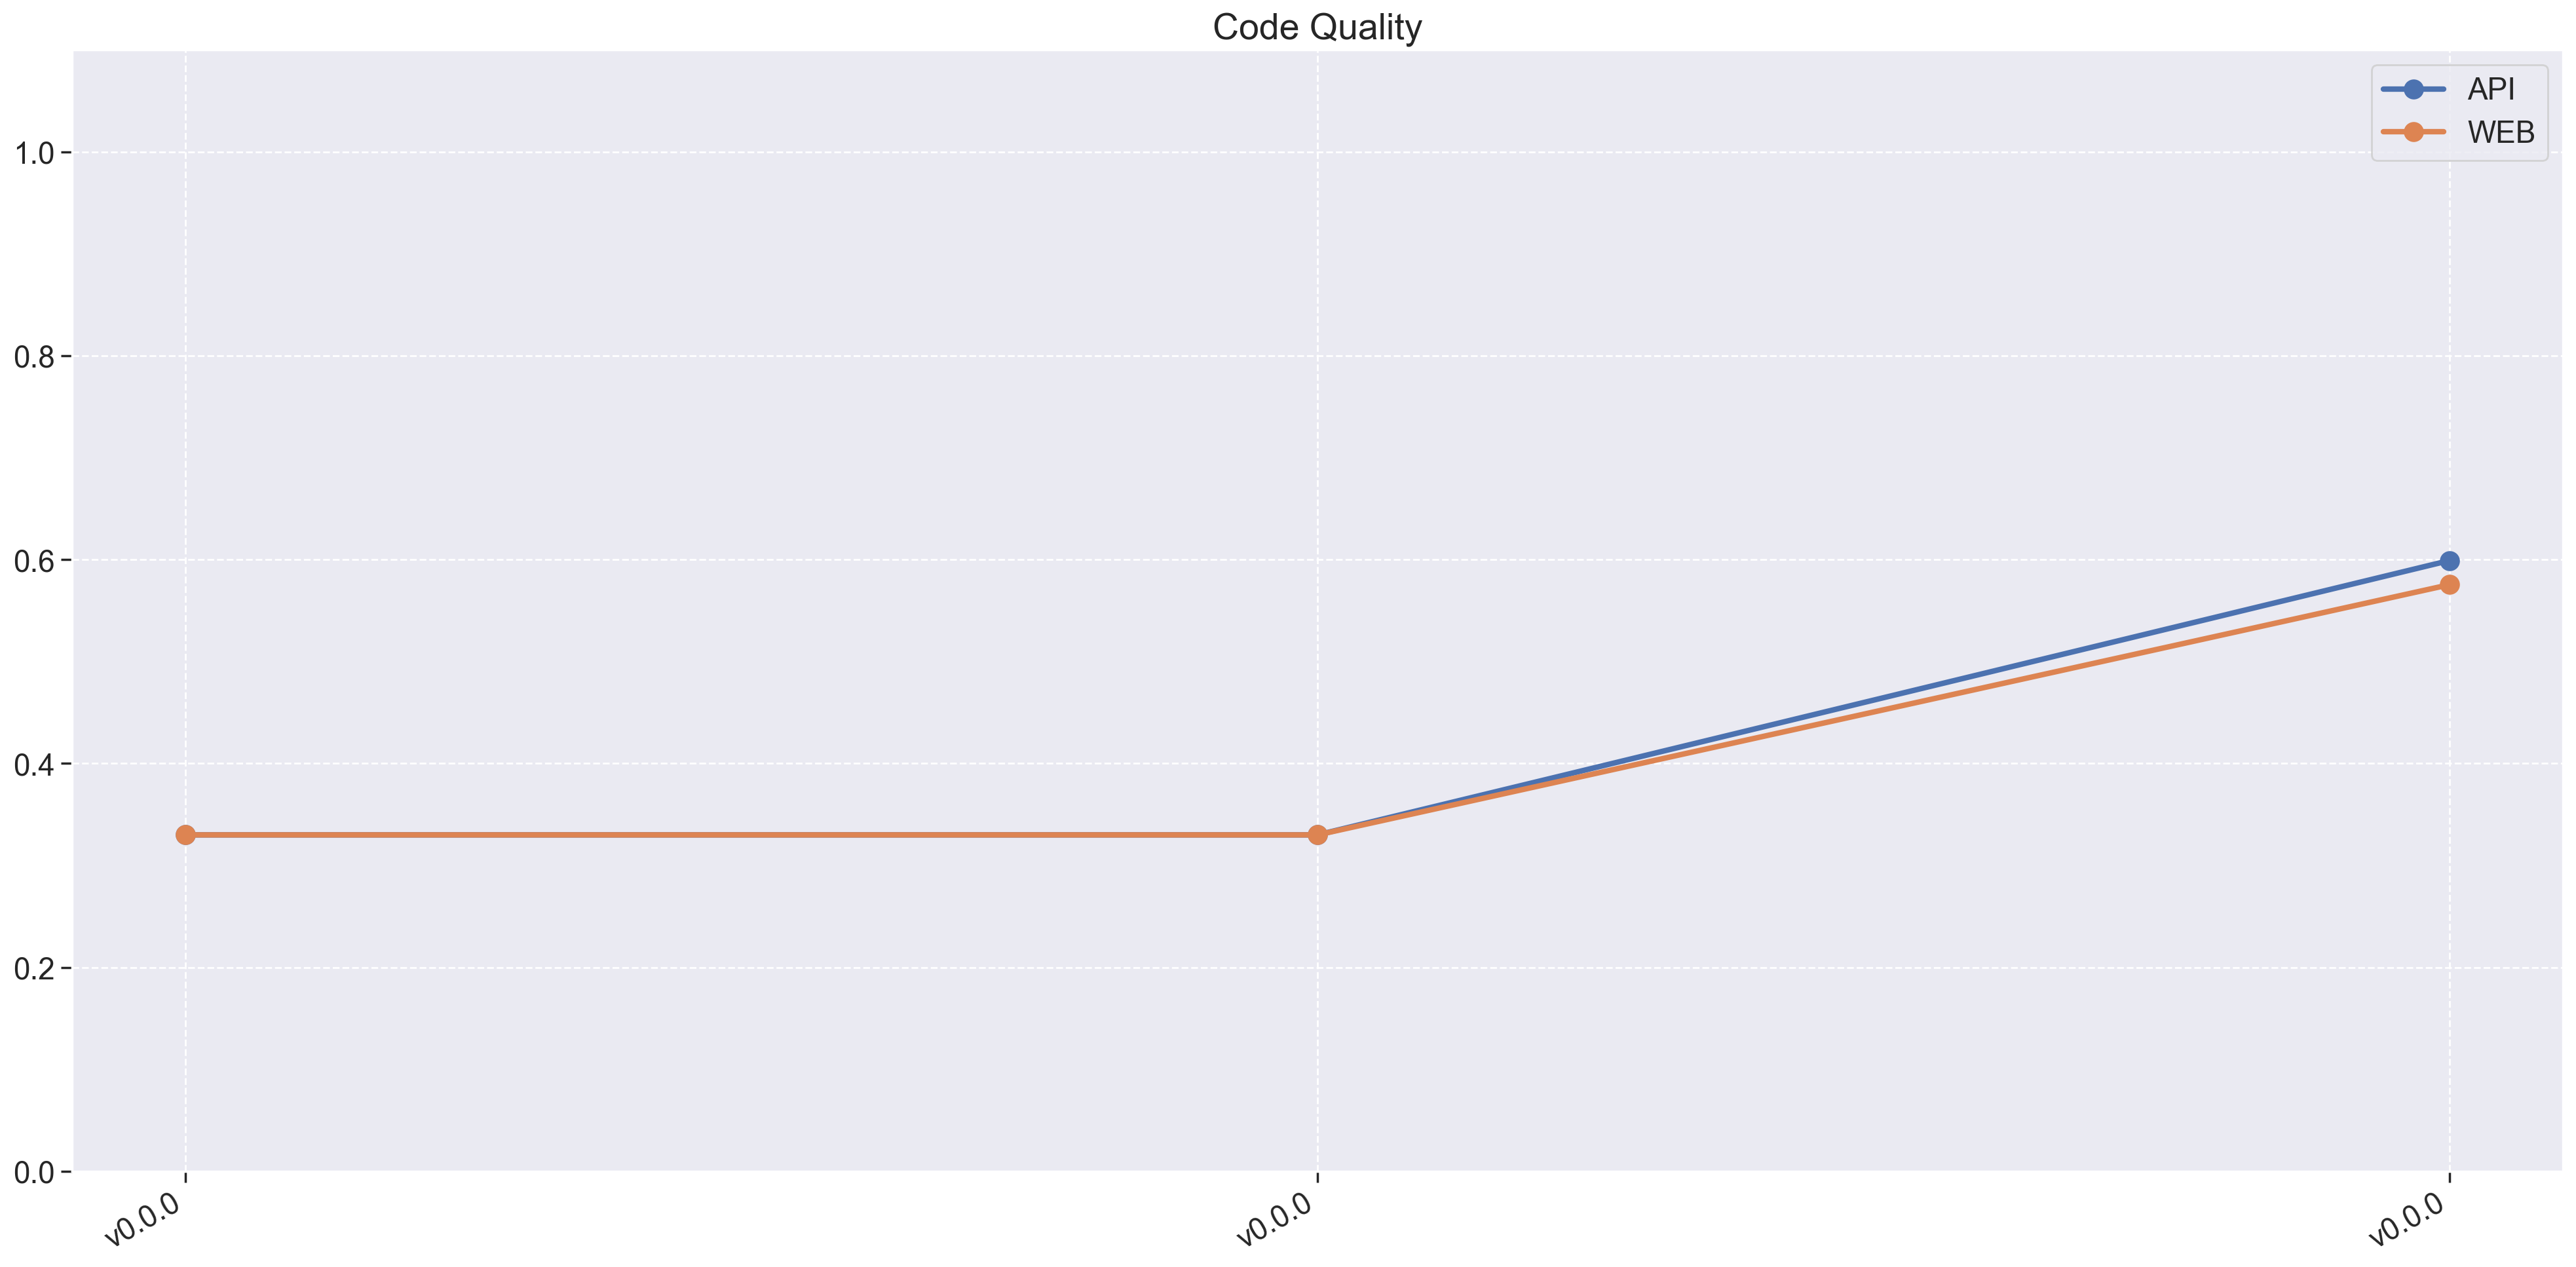

In [13]:
fig = plt.figure(figsize=(20, 10))
for name, data in metrics.items():
    x = range(len(data))
    plt.plot(x, data['code_quality'], linewidth=3, marker='o', markersize=10, label=name)
    plt.xticks(x, data['version'].tolist(), rotation=30, ha='right')
plt.ylim(0, 1.1)
plt.title('Code Quality', fontsize=20)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Testing Status

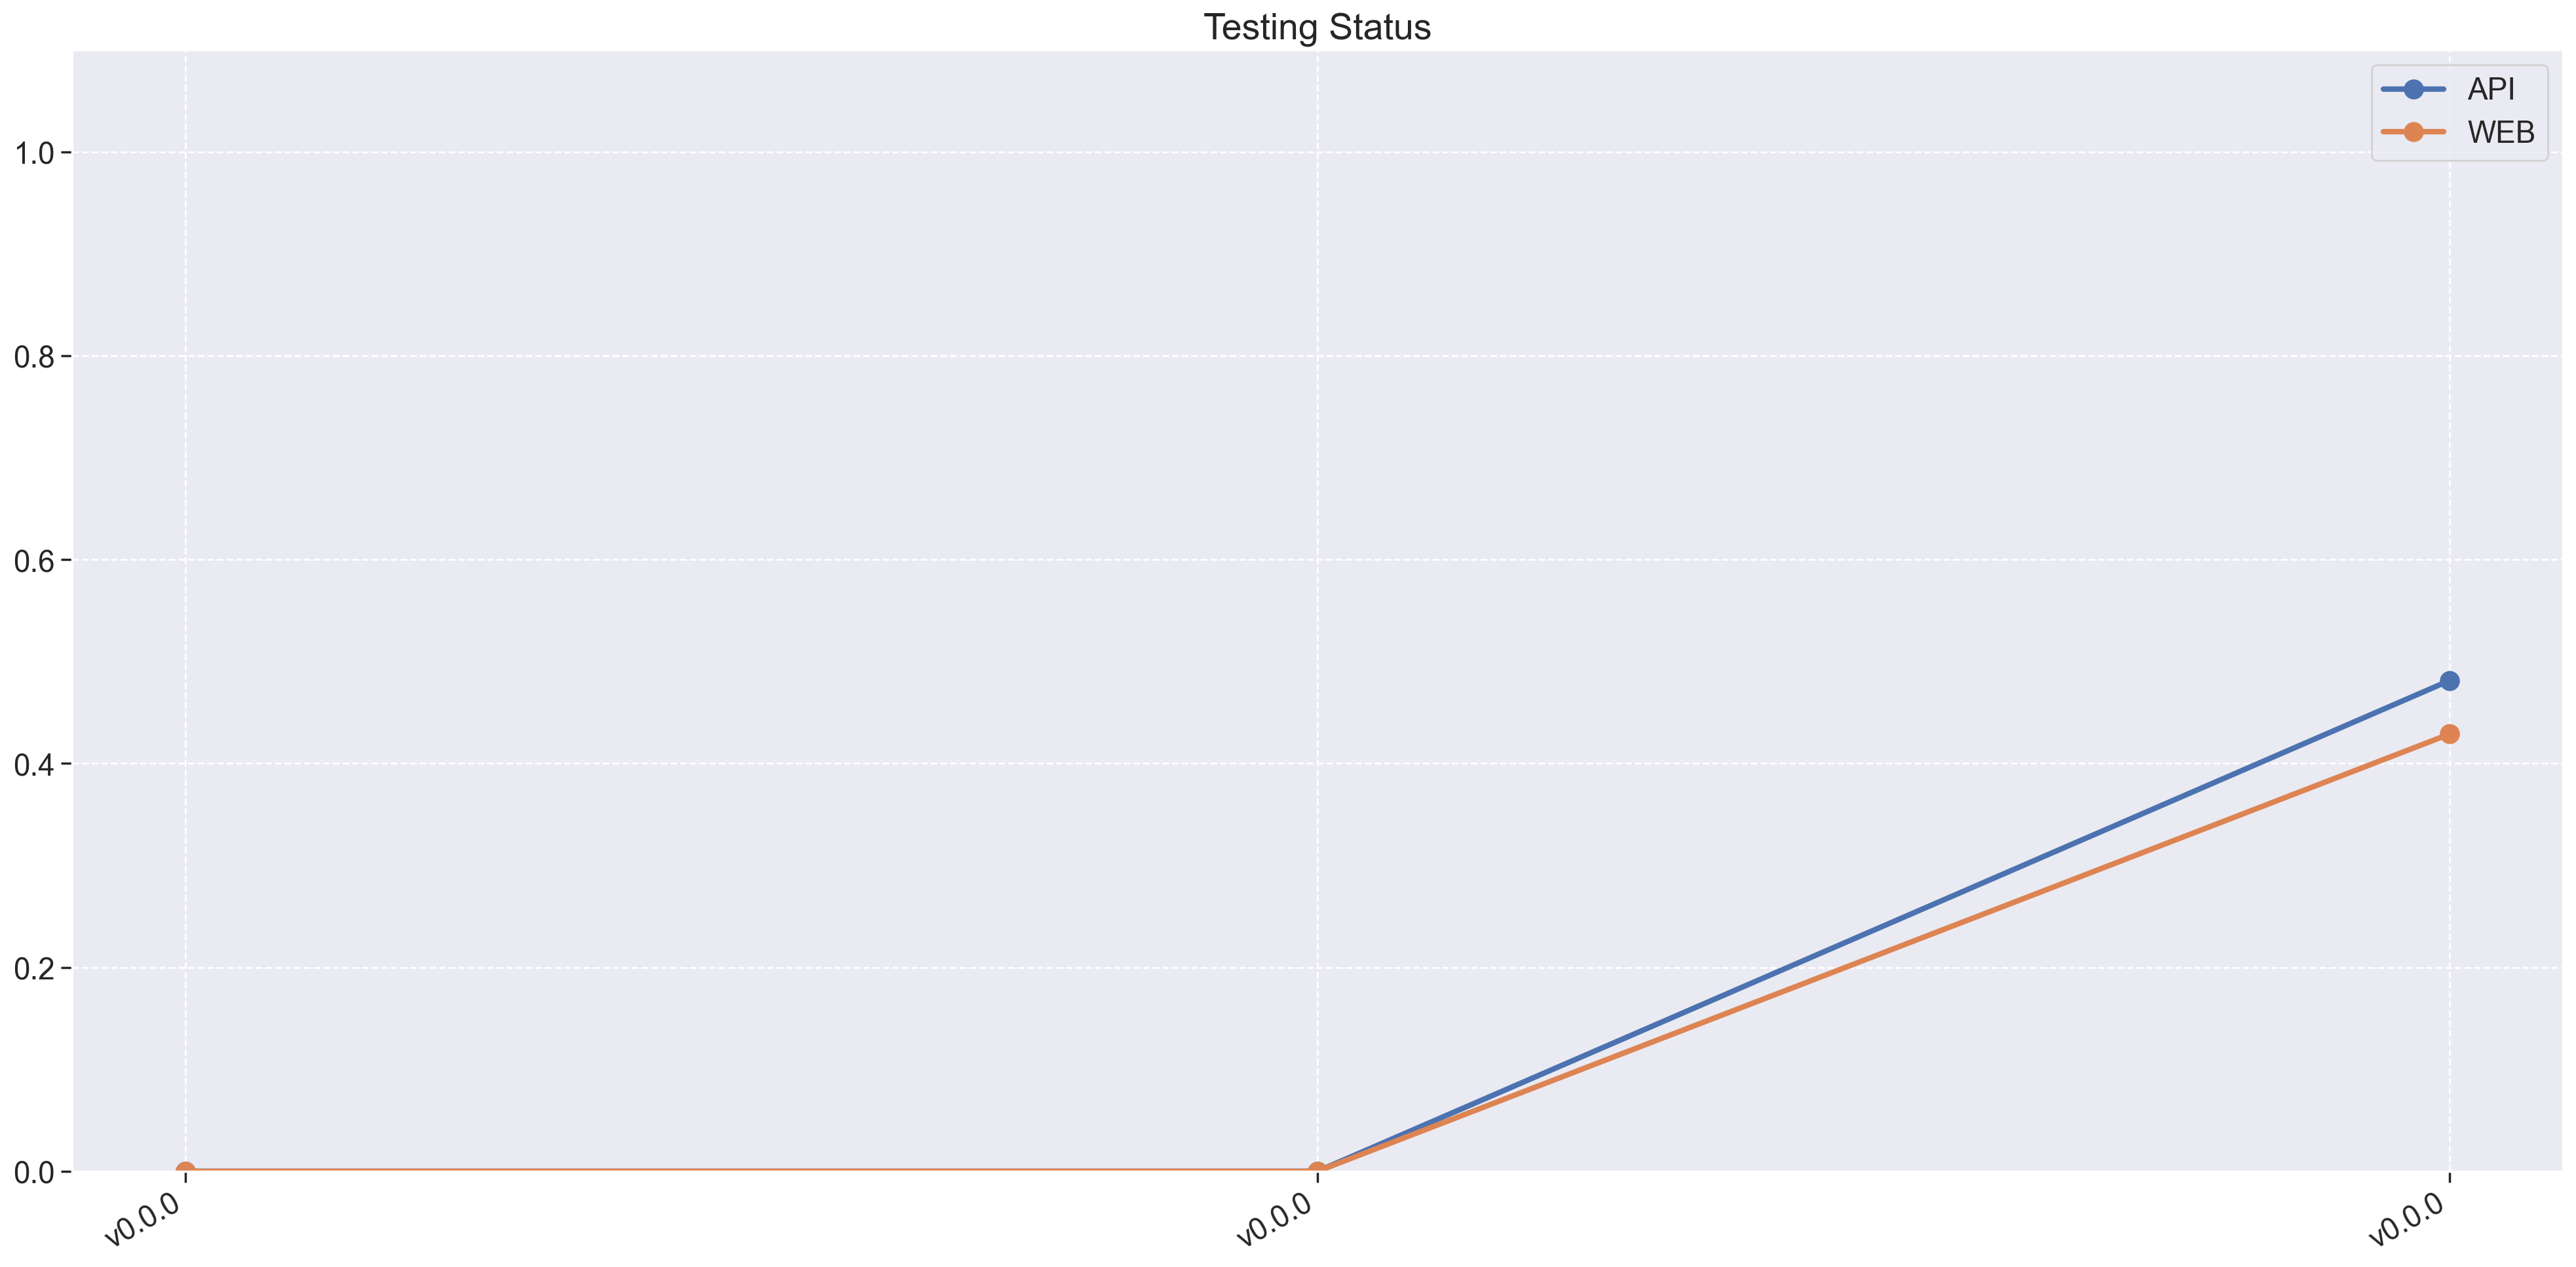

In [14]:
fig = plt.figure(figsize=(20, 10))
for name, data in metrics.items():
    x = range(len(data))
    plt.plot(x, data['testing_status'], linewidth=3, marker='o', markersize=10, label=name)
    plt.xticks(x, data['version'].tolist(), rotation=30, ha='right')
plt.ylim(0, 1.1)
plt.title('Testing Status', fontsize=20)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Aggregations — Maintainability, Reliability e Total

In [15]:
for name, data in metrics.items():
    data['Maintainability'] = data['code_quality']   * pc1
    data['Reliability']     = data['testing_status'] * pc2
    data['total']           = data['Maintainability'] + data['Reliability']

## Análise estatística por repositório


=== API ===

Maintainability:
mean      0.209870
median    0.165000
std       0.077718
min       0.165000
max       0.299611

Reliability:
mean      0.080250
median    0.000000
std       0.138997
min       0.000000
max       0.240750


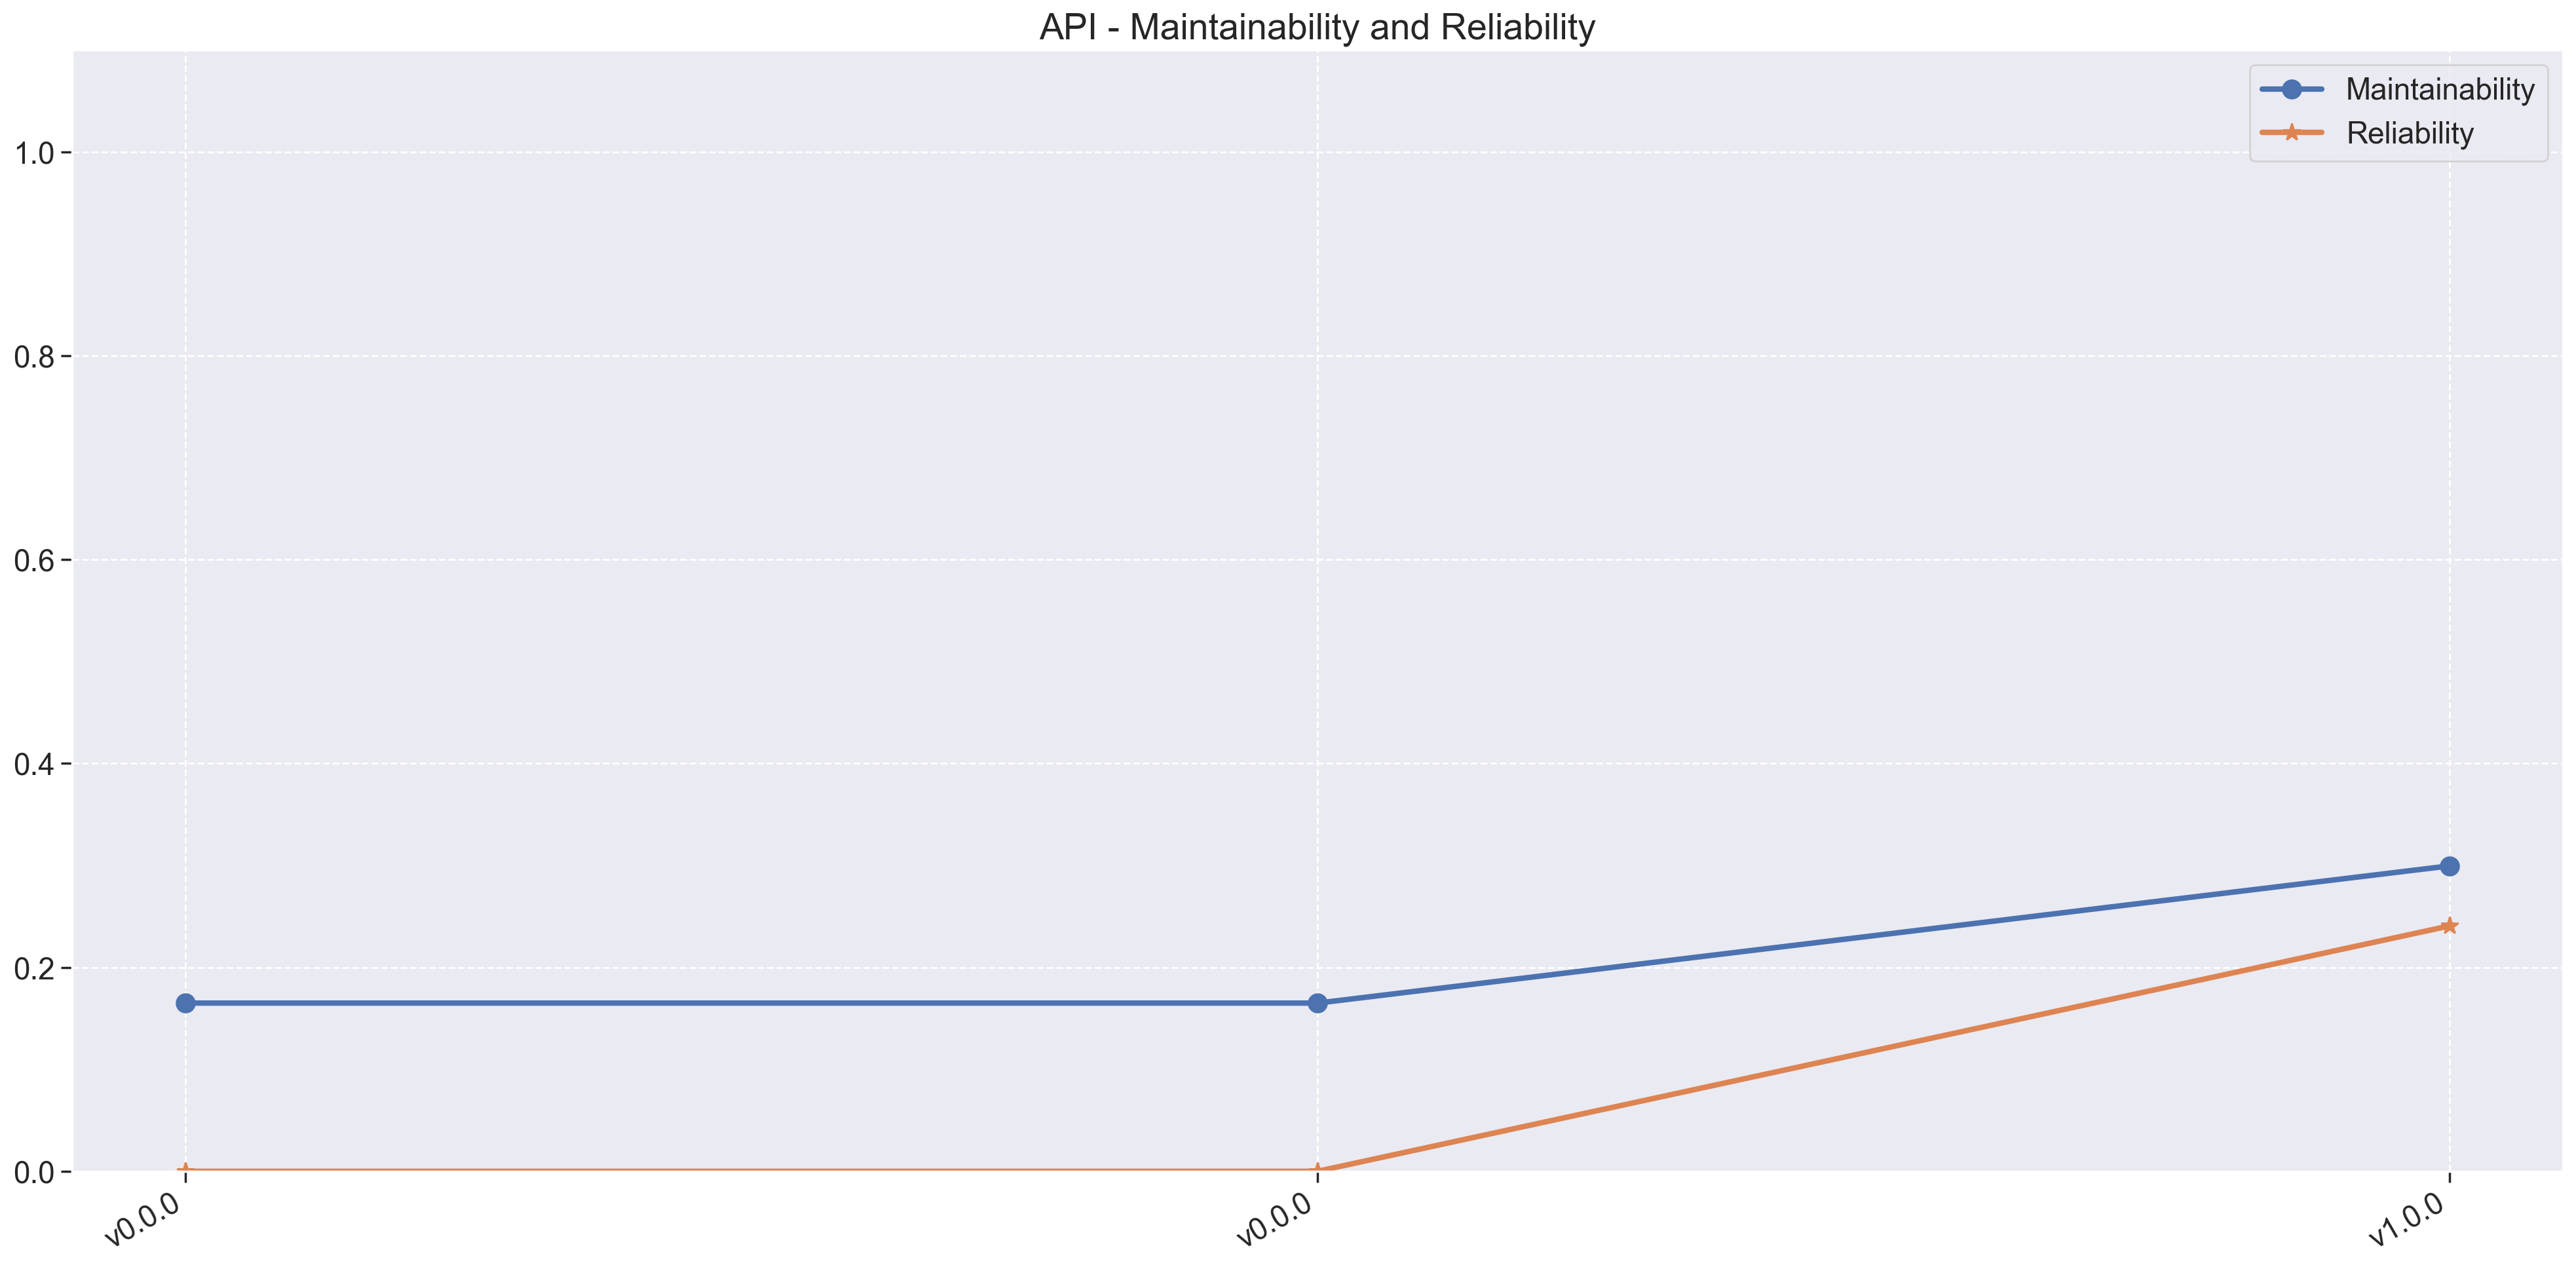

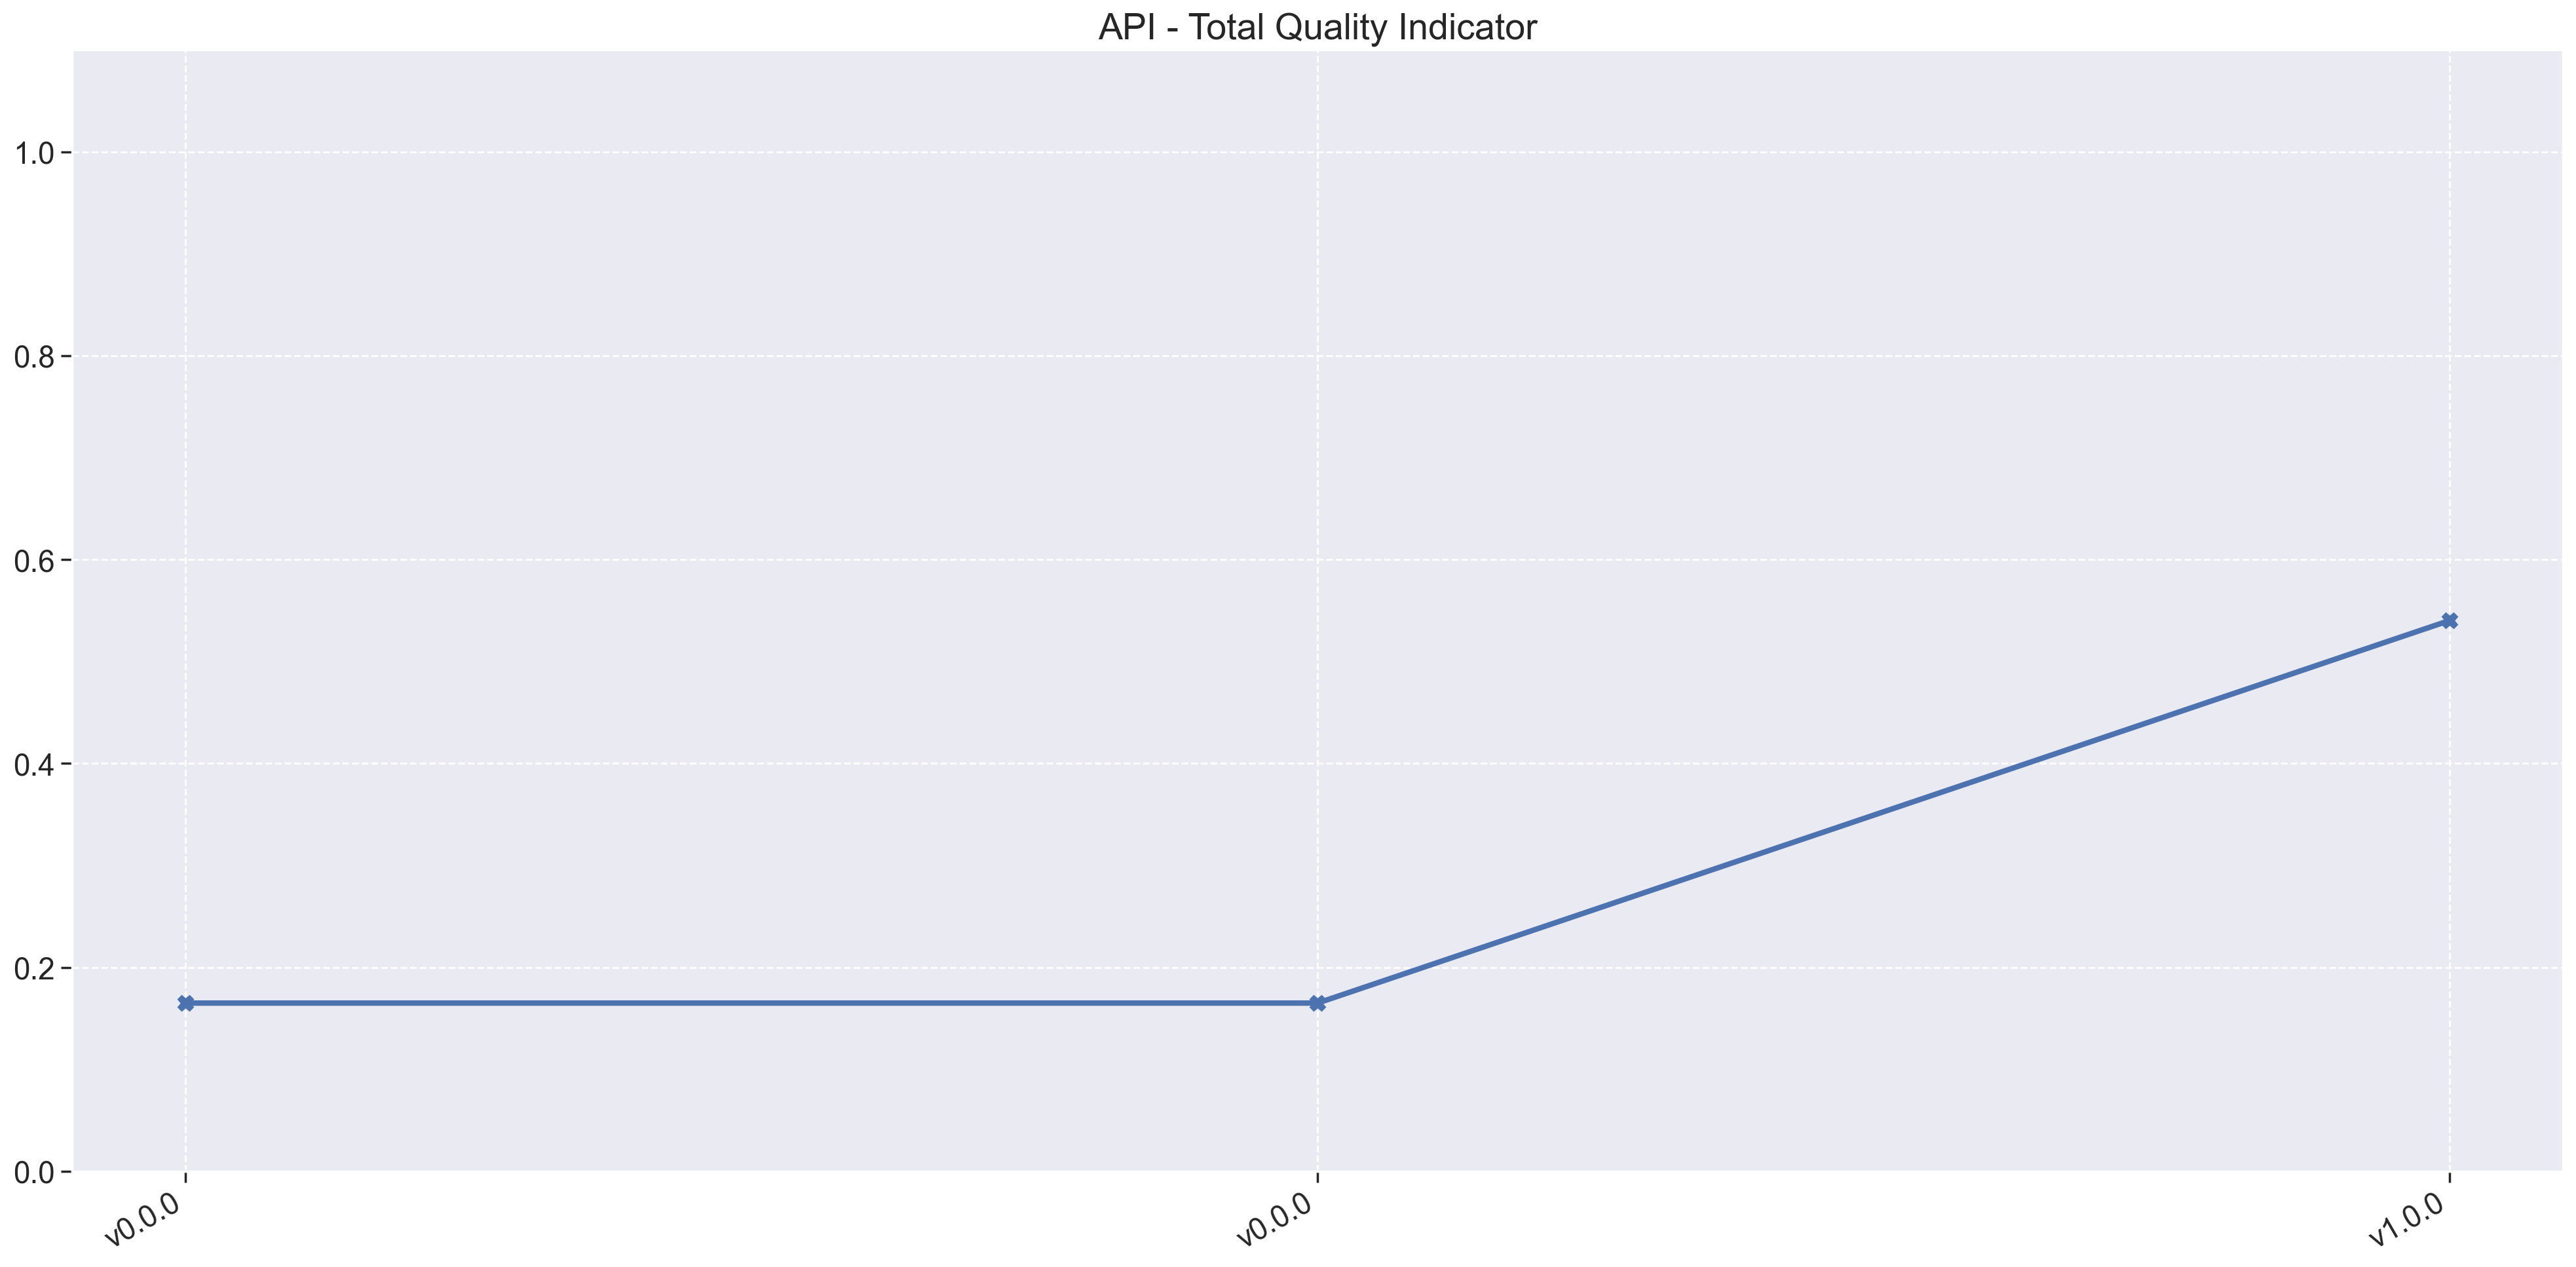


=== WEB ===

Maintainability:
mean      0.205915
median    0.165000
std       0.070866
min       0.165000
max       0.287744

Reliability:
mean      0.071500
median    0.000000
std       0.123842
min       0.000000
max       0.214500


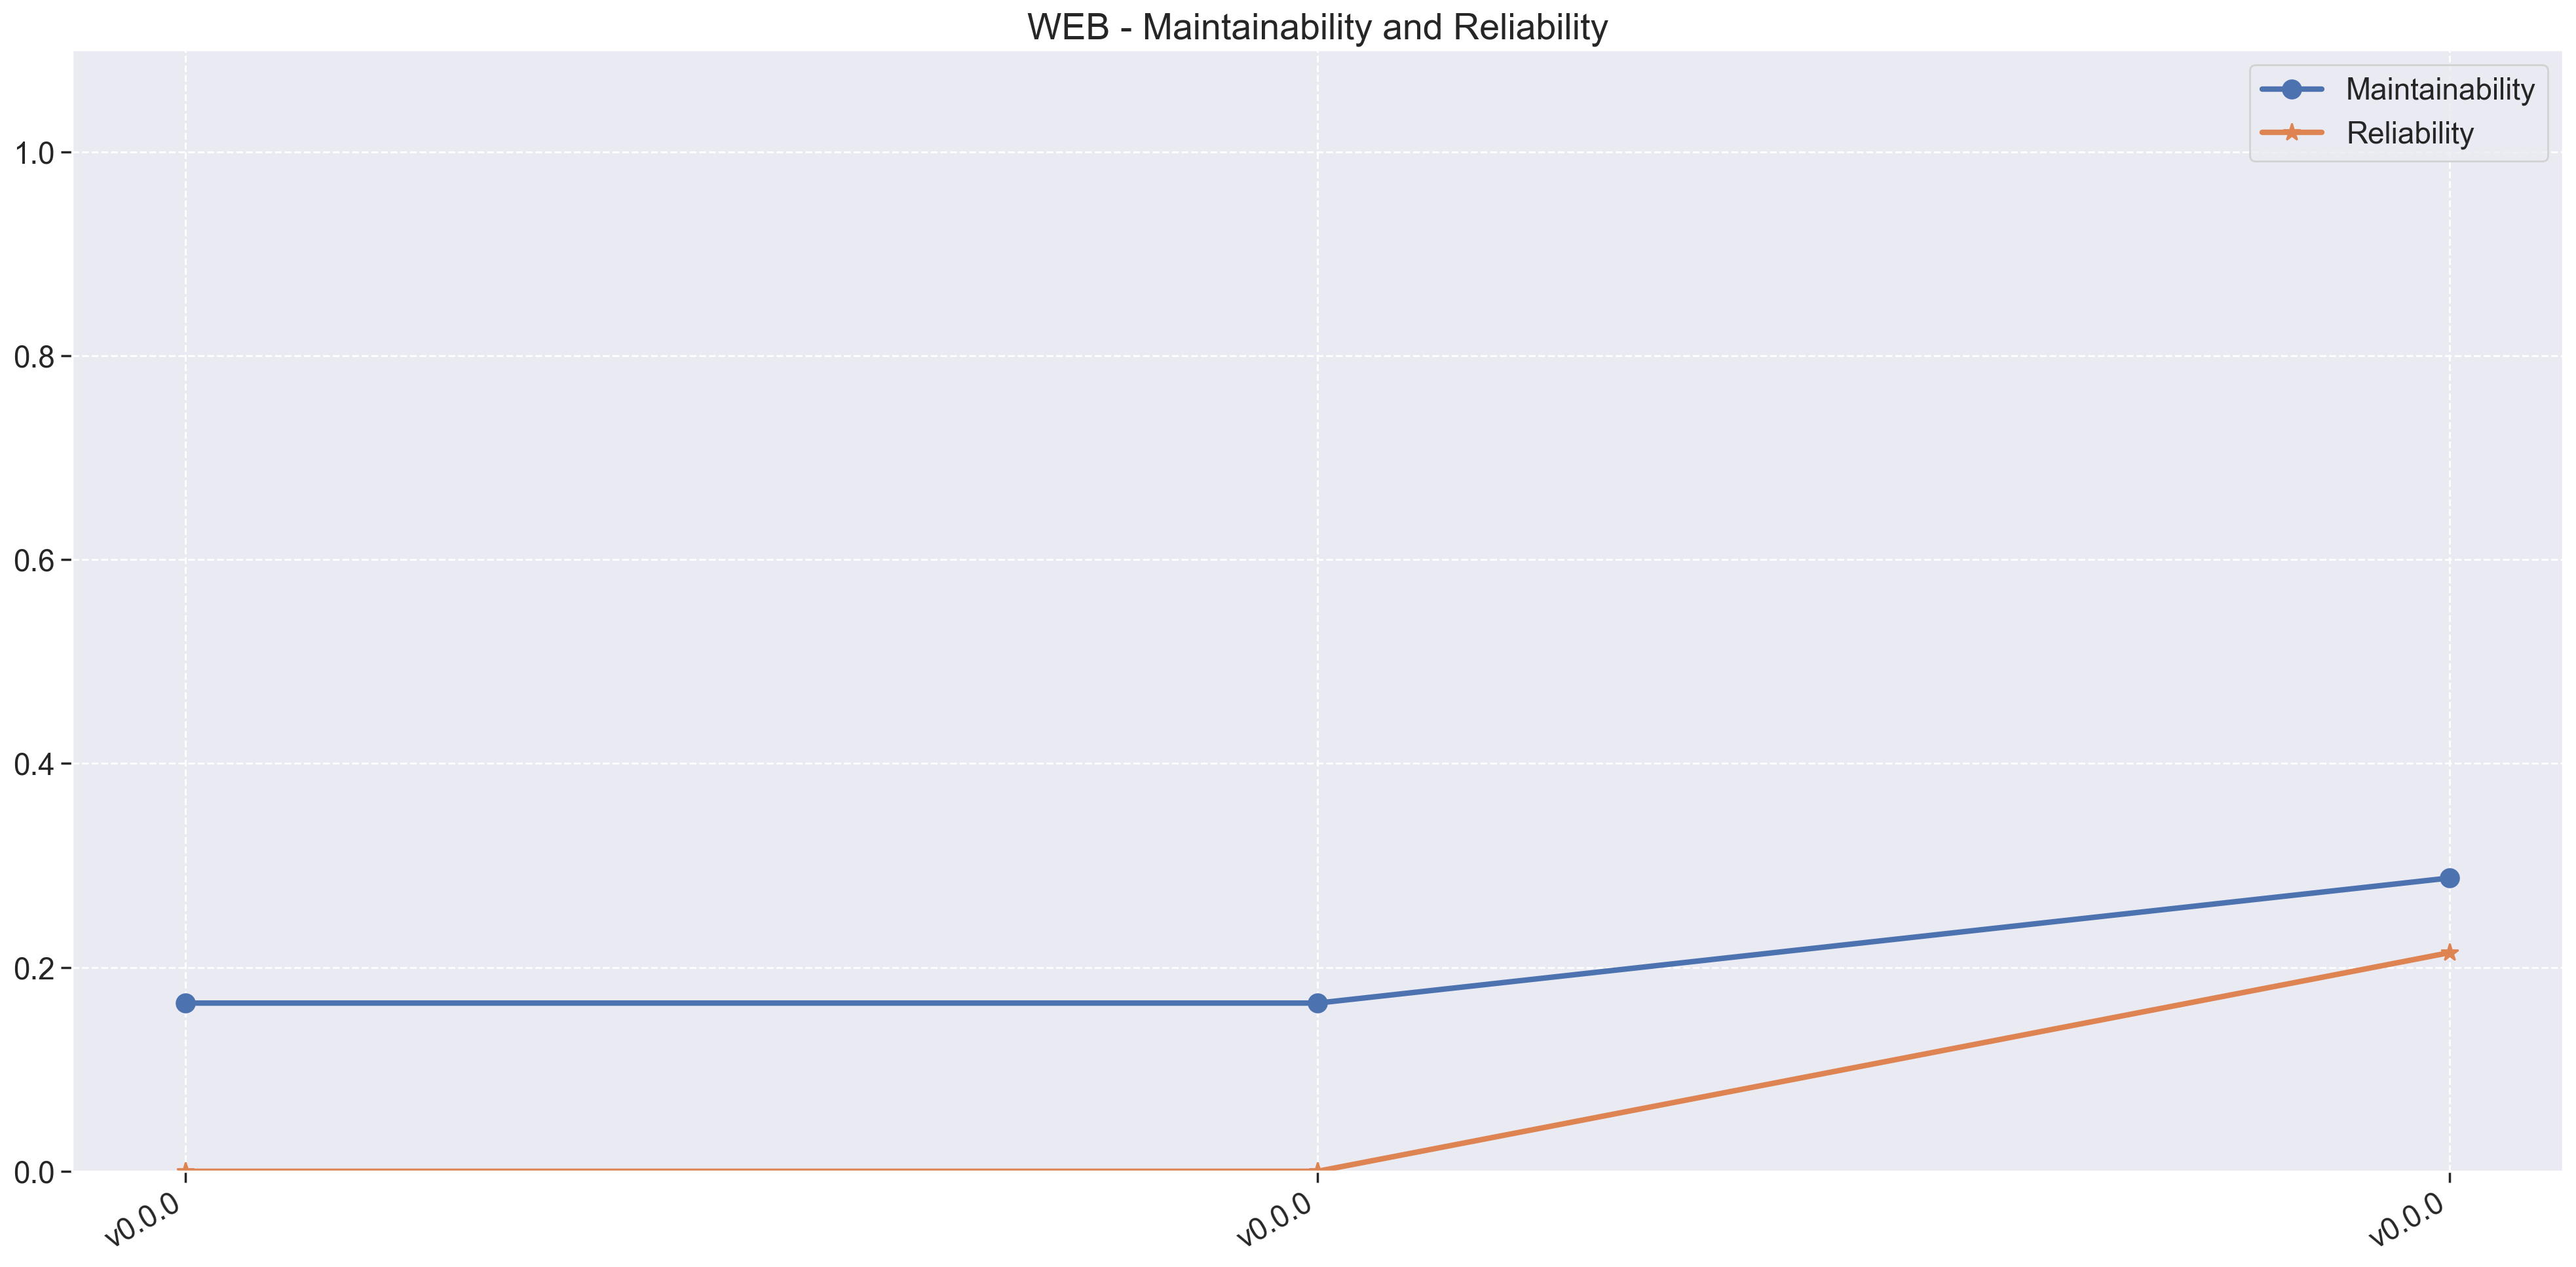

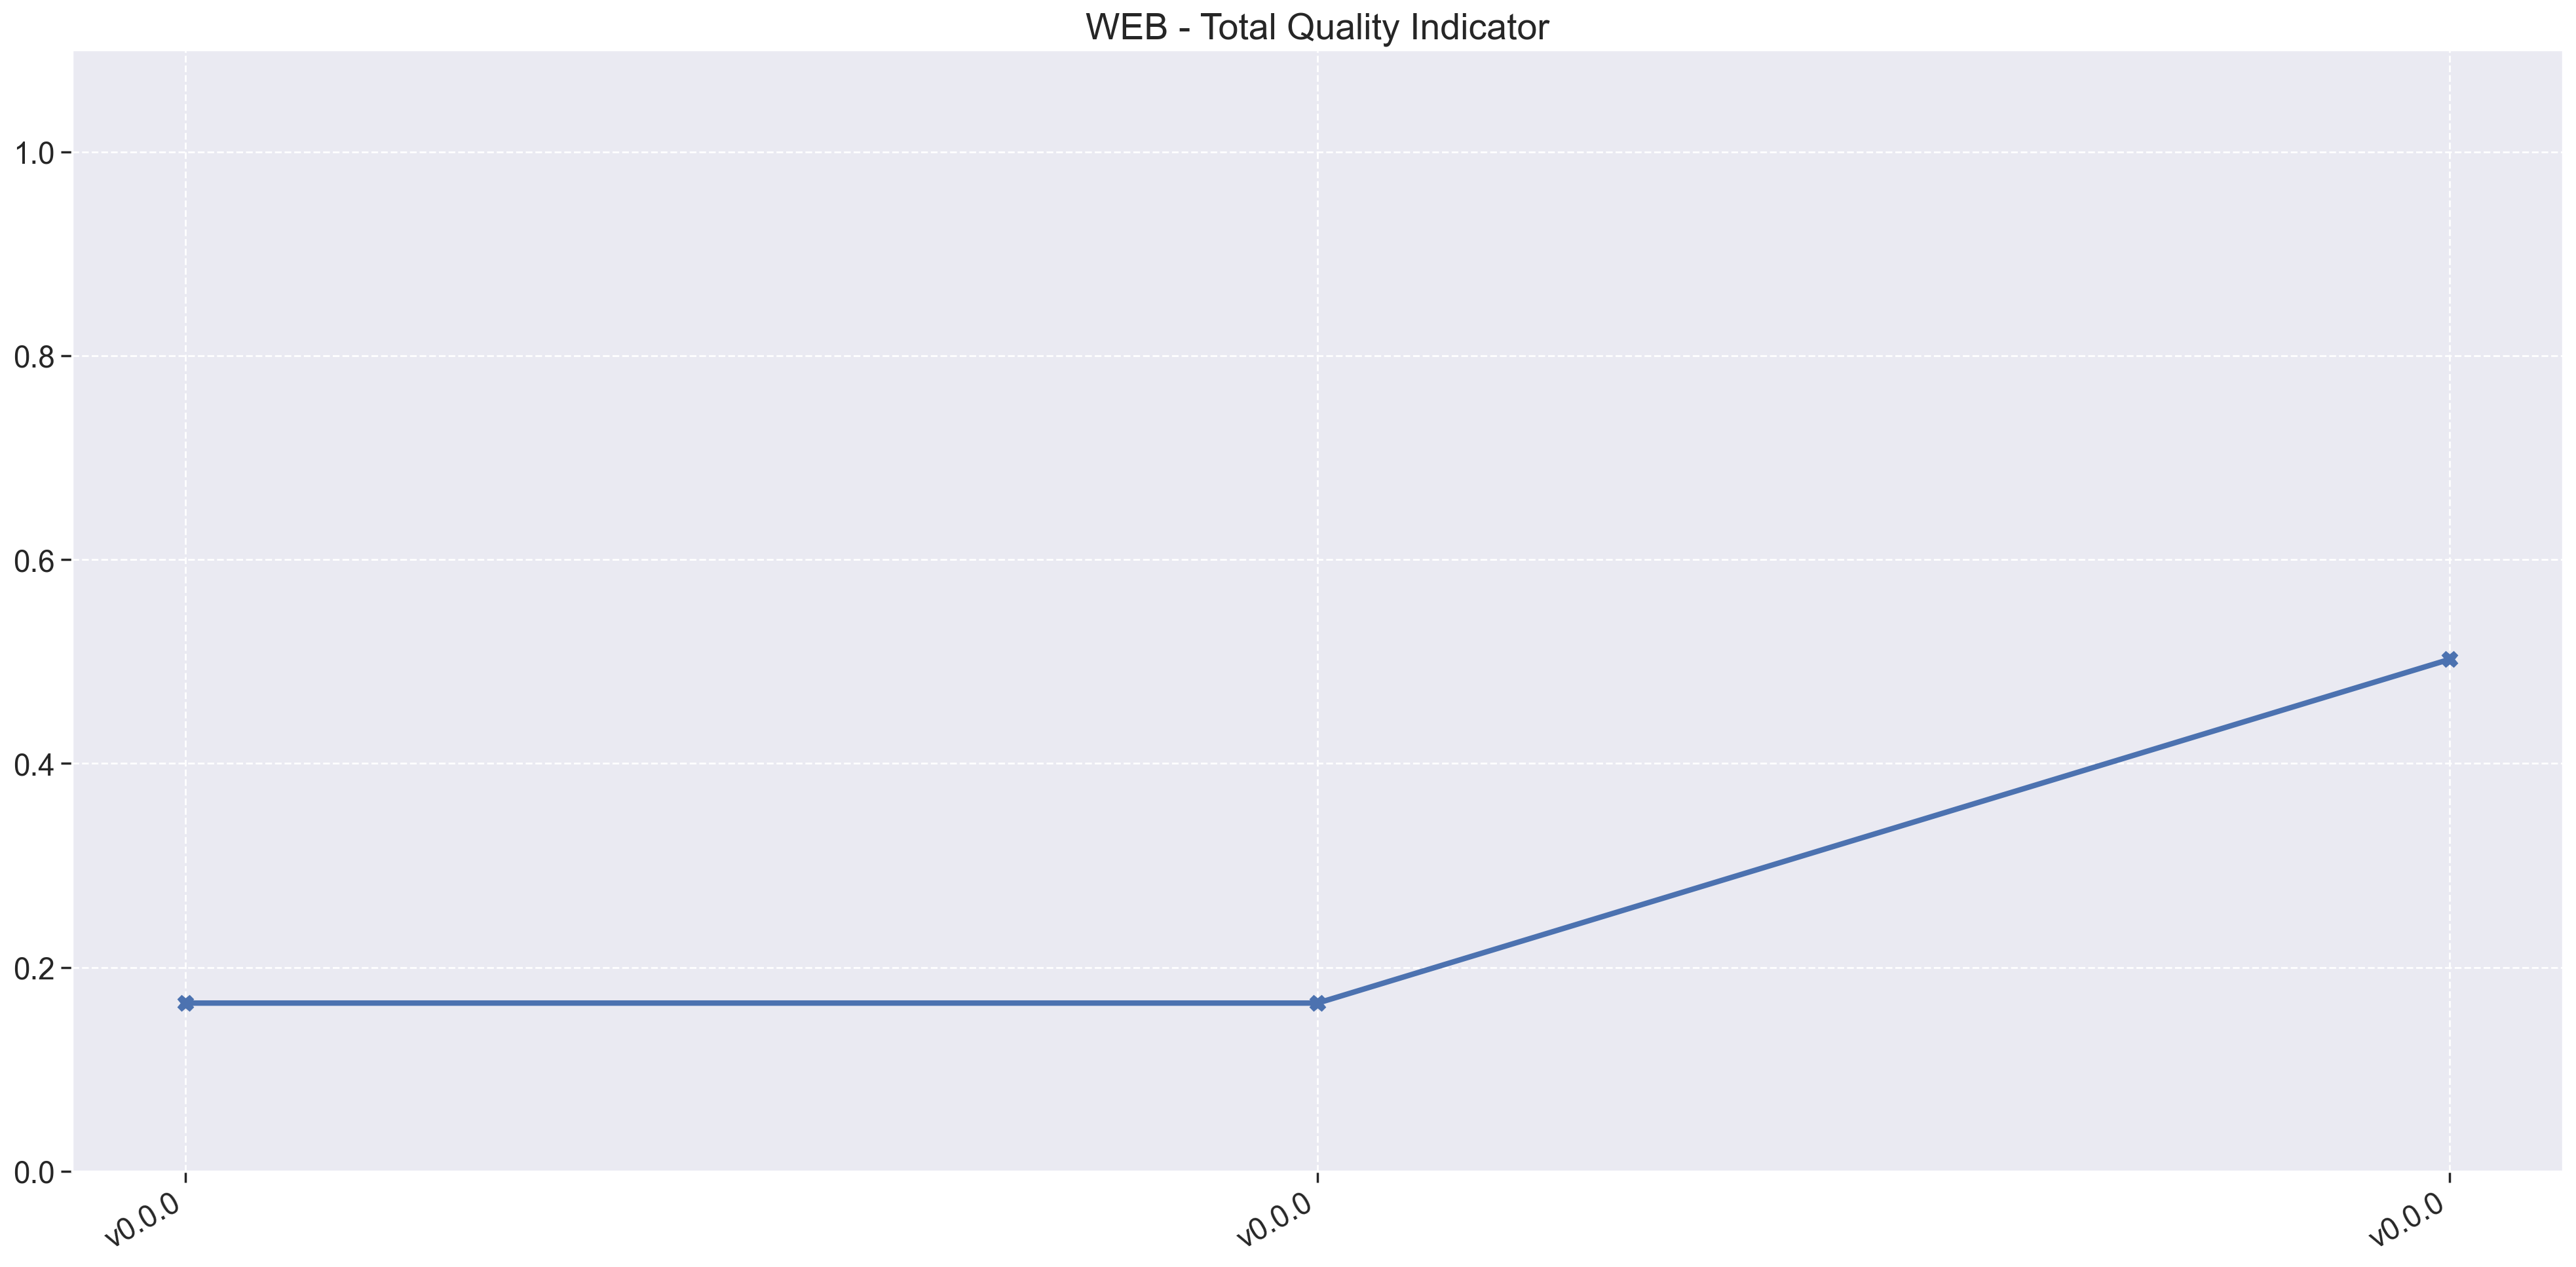

In [16]:
def analysis(data, name):
    print(f'\n=== {name} ===')
    for char in ['Maintainability', 'Reliability']:
        s = data[char].agg(['mean', 'median', 'std', 'min', 'max'])
        print(f'\n{char}:')
        print(s.to_string())

    x = range(len(data))
    labels = data['version'].tolist()

    fig = plt.figure(figsize=(20, 10))
    plt.plot(x, data['Maintainability'], linewidth=3, marker='o', markersize=10, label='Maintainability')
    plt.plot(x, data['Reliability'],     linewidth=3, marker='*', markersize=10, label='Reliability')
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylim(0.0, 1.1)
    plt.title(f'{name} - Maintainability and Reliability', fontsize=20)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    plt.plot(x, data['total'], linewidth=3, marker='X', markersize=8)
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylim(0.0, 1.1)
    plt.title(f'{name} - Total Quality Indicator', fontsize=20)
    plt.tight_layout()
    plt.show()

for name, data in metrics.items():
    analysis(data, name)

### Quality characteristic indicator (boxplot)

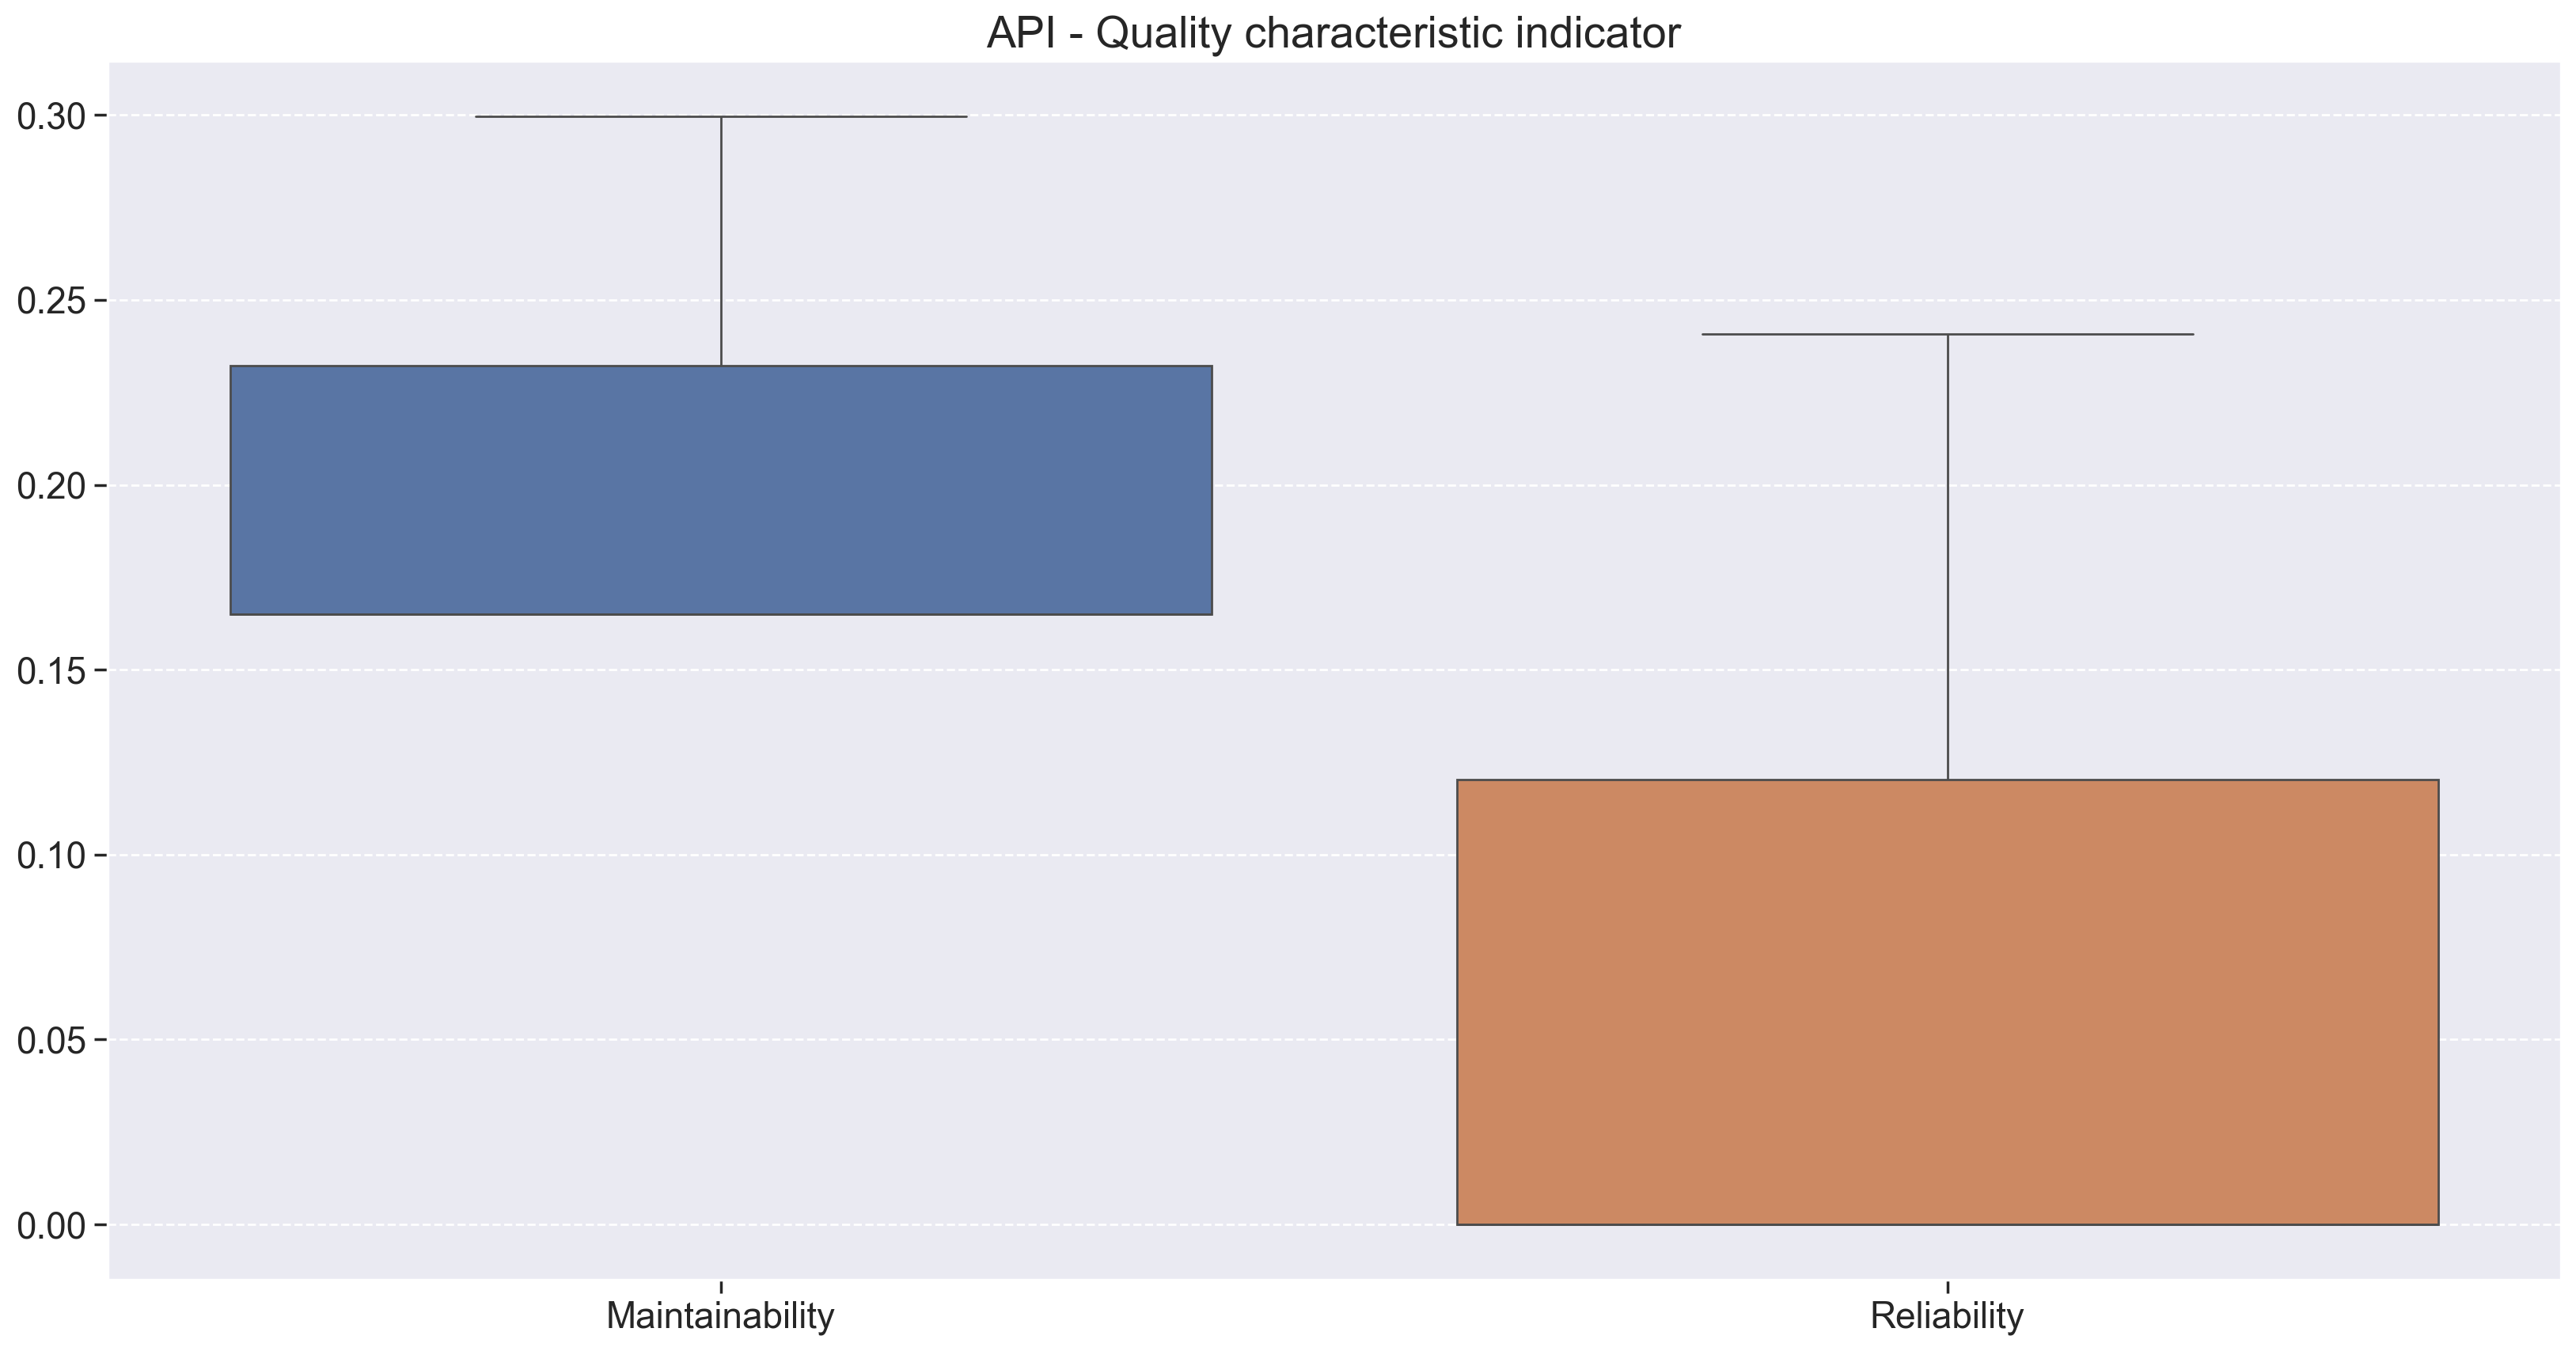

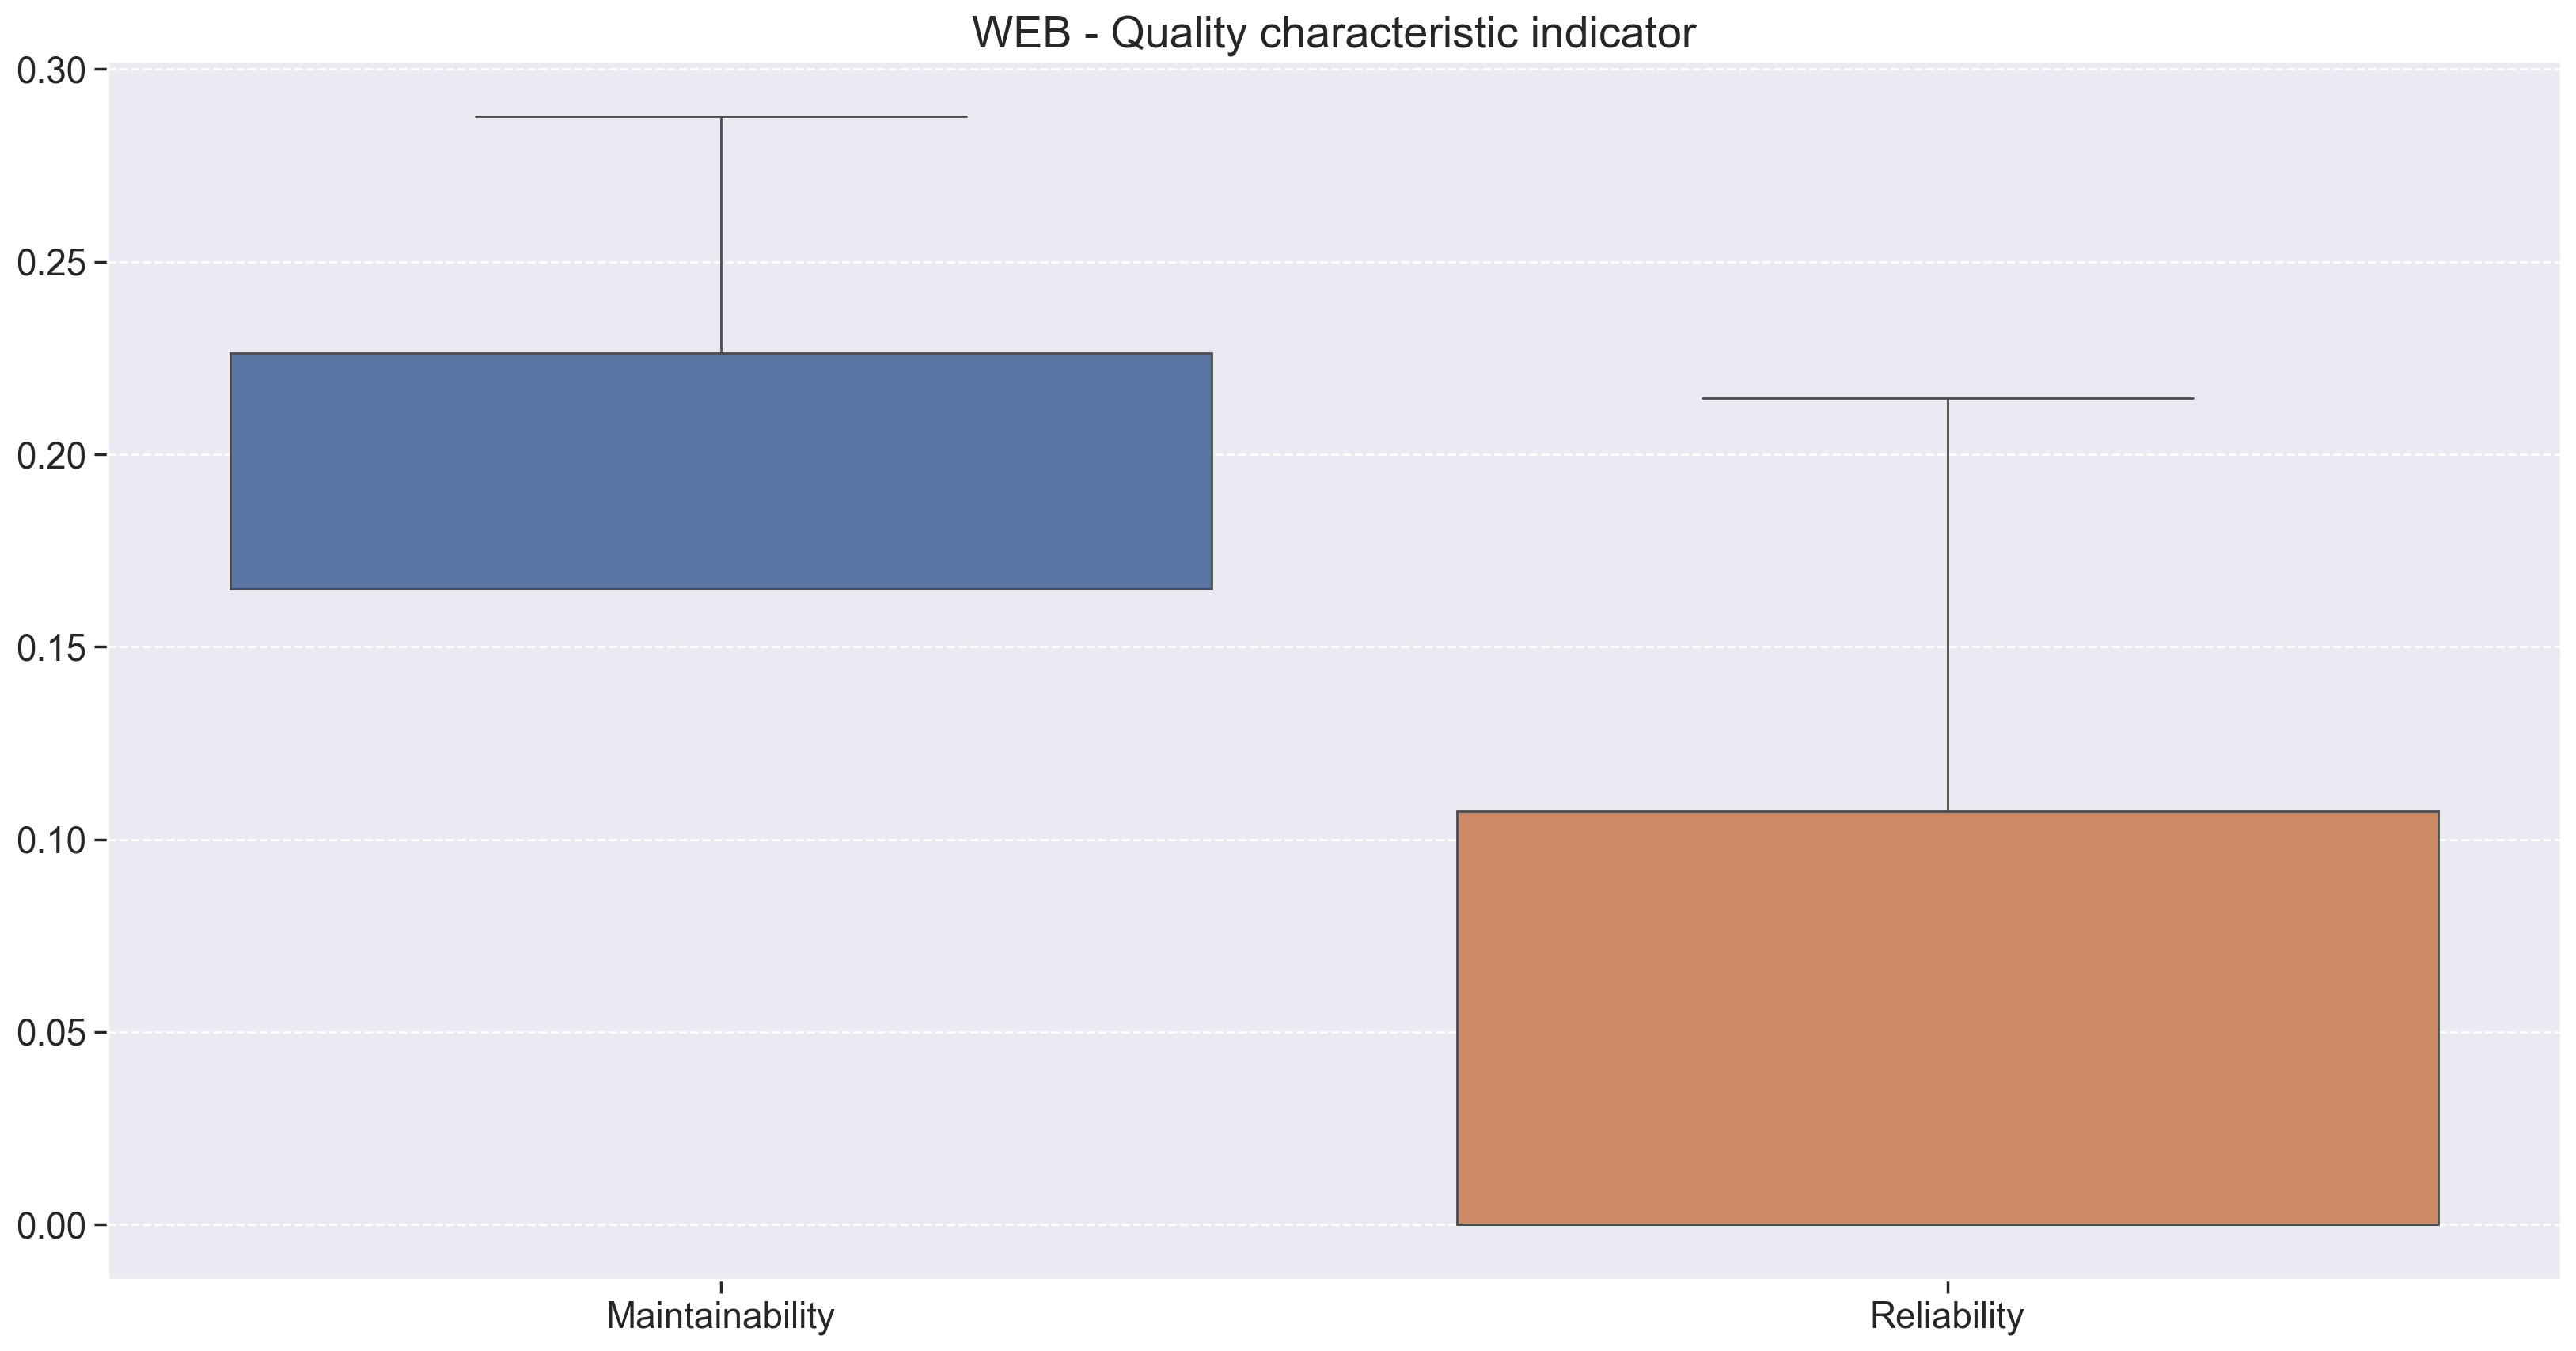

In [17]:
for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))
    sns.boxplot(data=data[['Maintainability', 'Reliability']])
    plt.title(f'{name} - Quality characteristic indicator', fontsize=20)
    plt.show()

### Quality indicator — todos os repositórios

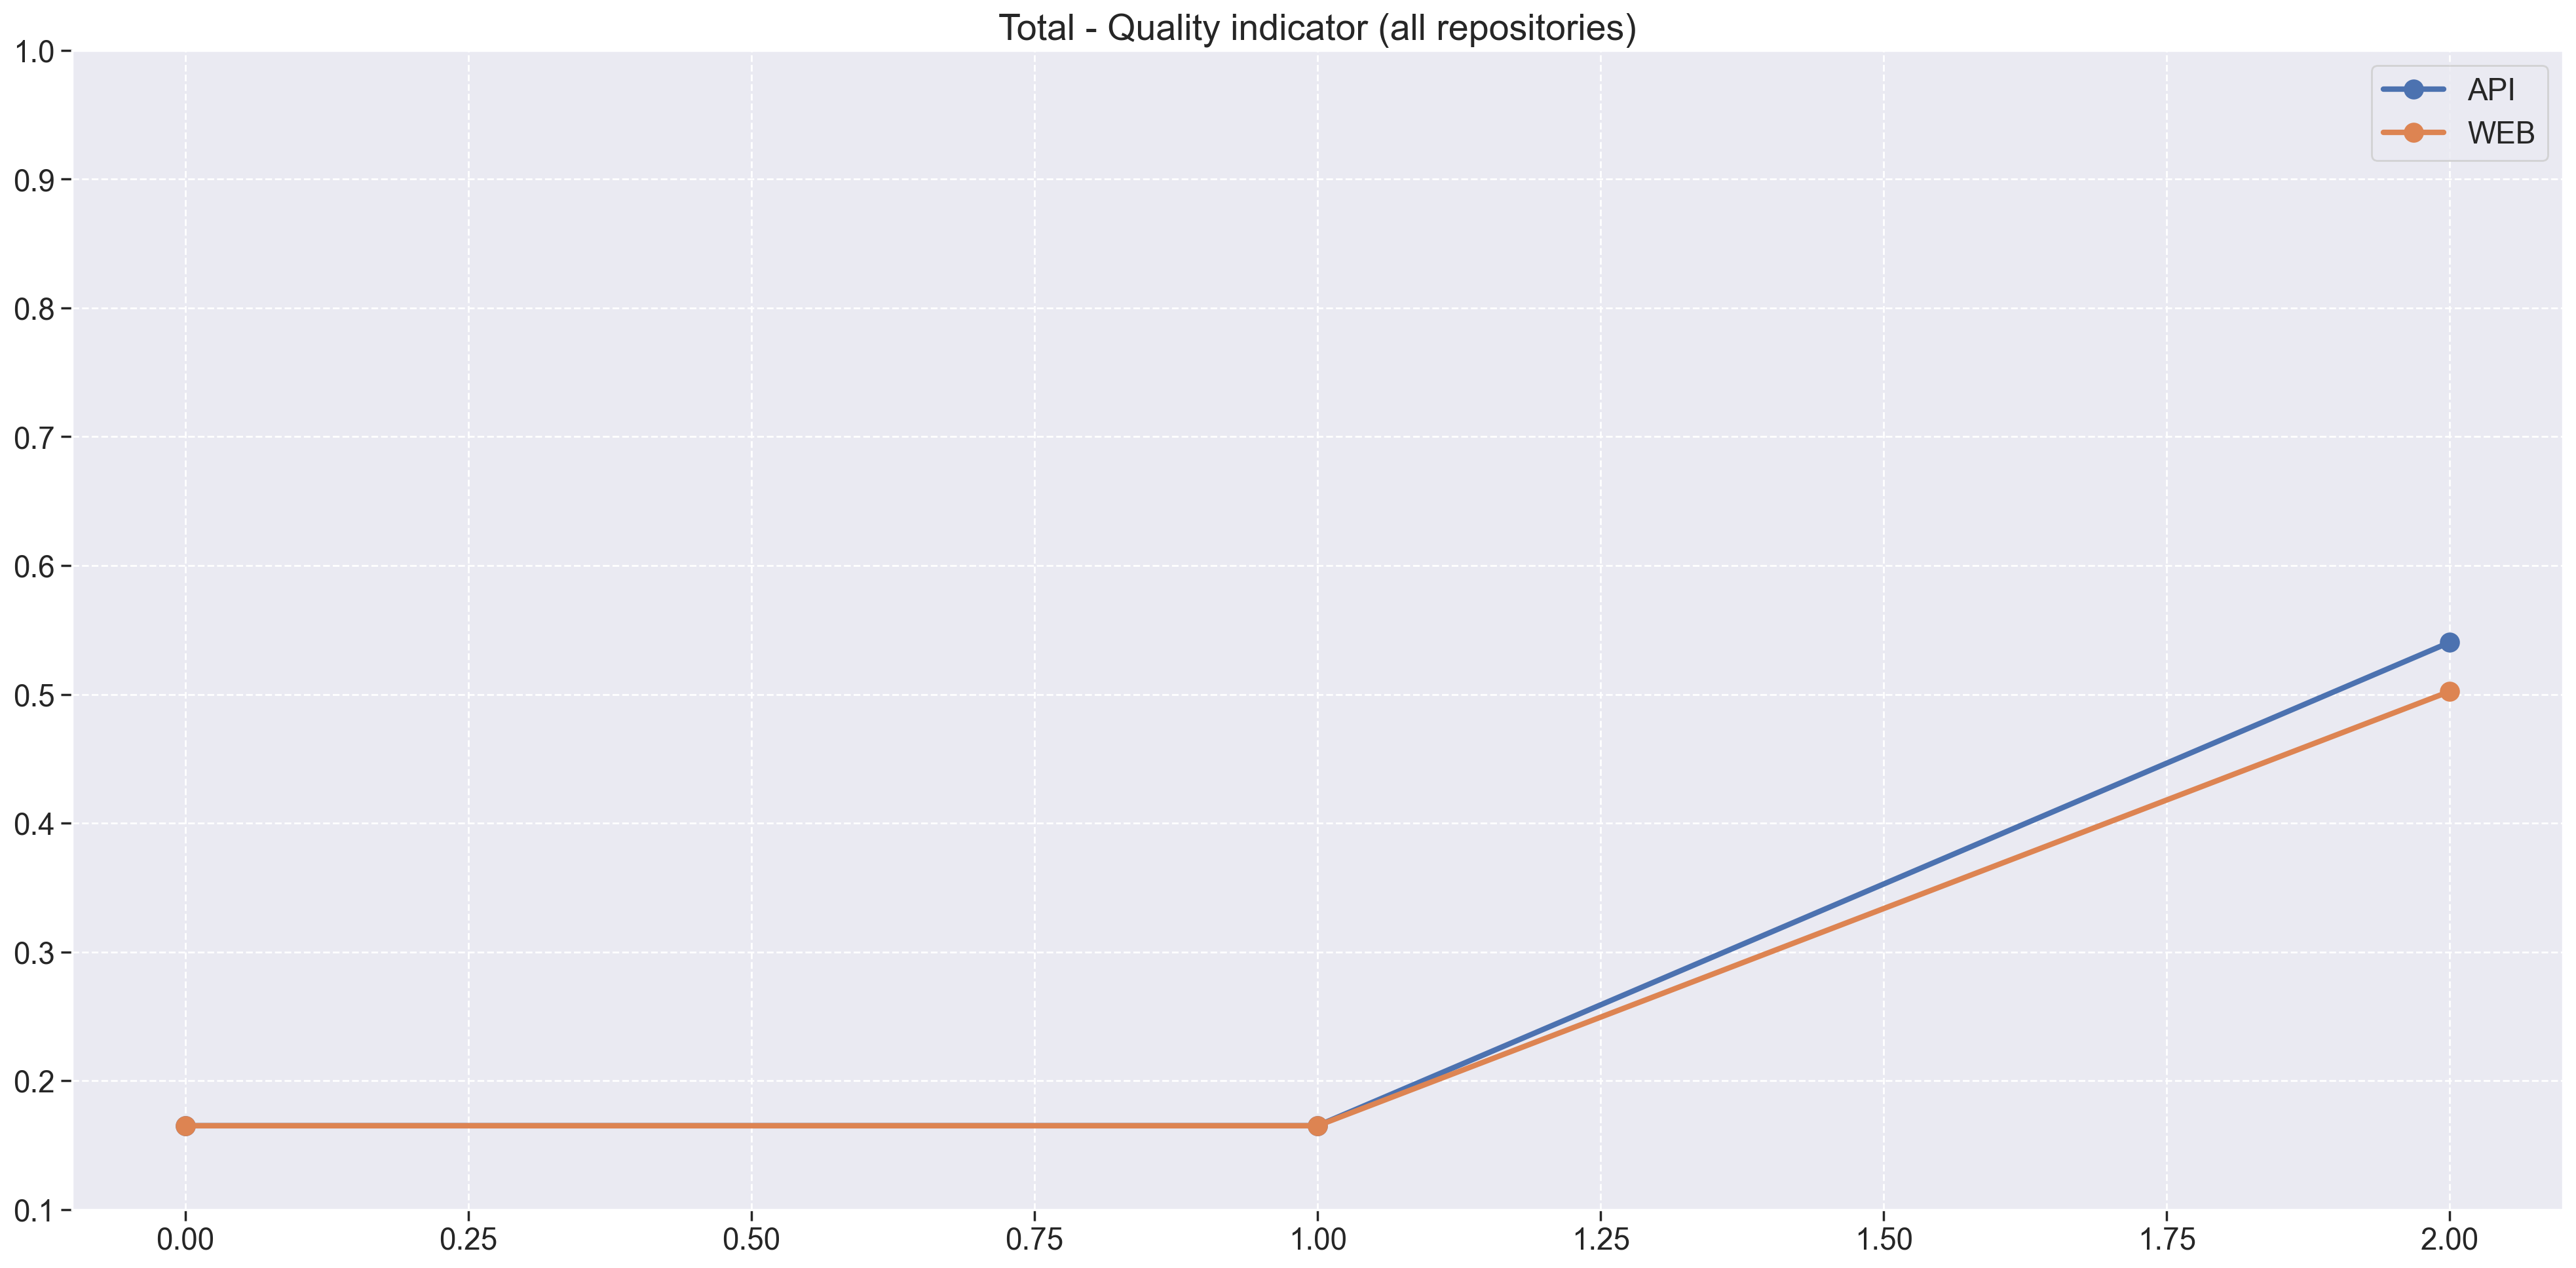

In [18]:
fig = plt.figure(figsize=(20, 10))
for name, data in metrics.items():
    x = range(len(data))
    plt.plot(x, data['total'], linewidth=3, marker='o', markersize=10, label=name)
plt.ylim(0.1, 1.0)
plt.title('Total - Quality indicator (all repositories)', fontsize=20)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Export data

In [19]:
metrics_df = pd.concat(metrics.values(), ignore_index=True)
display(metrics_df)

os.makedirs('./data', exist_ok=True)
now = datetime.datetime.now().strftime('%m-%d-%Y--%H-%M-%S')
metrics_df.to_excel(f'./data/fga-eps-mds-2026_1_UNB-AnatoQuizUp--{now}.xlsx', index=False)
metrics_df.to_csv(f'./data/fga-eps-mds-2026_1_UNB-AnatoQuizUp--{now}.csv',   index=False)
print('Exportado com sucesso!')

,repository,datetime,version,ncloc,complexity,comments,duplication,test_success,fast_tests,coverage,code_quality,testing_status,Maintainability,Reliability,total
0,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-01-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000,0.330000,0.0000,0.165000,0.00000,0.165000
1,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-10-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000,0.330000,0.0000,0.165000,0.00000,0.165000
2,fga-eps-mds-2026_1_UNB-AnatoQuizUp-API,04-27-2026-02-33-15,v1.0.0,3082.0,0.815823,0.0,1.0,0.0,0.0,0.963,0.599222,0.4815,0.299611,0.24075,0.540361
3,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-01-2026-04-01-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000,0.330000,0.0000,0.165000,0.00000,0.165000
4,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-10-2026-00-00-00,v0.0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000,0.330000,0.0000,0.165000,0.00000,0.165000
5,fga-eps-mds-2026_1_UNB-AnatoQuizUp-WEB,04-27-2026-02-16-43,v0.0.0,2561.0,0.743902,0.0,1.0,0.0,0.0,0.858,0.575488,0.4290,0.287744,0.21450,0.502244


Exportado com sucesso!
